In [313]:
# %%
# Cell 01 - Setup imports
# Adds repo src path and imports shared loading, analysis, plotting, and multi-fish helpers.

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.data_loading as exio
import src.analysis_tools as at
import seaborn as sns
import importlib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
import seaborn as sns
import src.stimuli_timeline as st
import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at
import src.multifish_analysis as mfa

importlib.reload(exio)
importlib.reload(at)
importlib.reload(plott)
importlib.reload(mfa)

build_active_neuron_matrices_all_fish = mfa.build_active_neuron_matrices_all_fish
build_active_neuron_overlap_matrices_all_fish = mfa.build_active_neuron_overlap_matrices_all_fish
build_pooled_active_trace_diagnostic = mfa.build_pooled_active_trace_diagnostic
build_zscore_response_matrices_all_fish = mfa.build_zscore_response_matrices_all_fish
build_neuron_stimulus_summary_table = mfa.build_neuron_stimulus_summary_table
add_selectivity_metrics_to_summary_table = mfa.add_selectivity_metrics_to_summary_table
classify_stimulus_specificity_summary_table = mfa.classify_stimulus_specificity_summary_table
build_stimulus_specificity_neuron_order = mfa.build_stimulus_specificity_neuron_order


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Cell 02 - Setup notes
Markdown separator for the import/setup section.


In [314]:
# %%
# Cell 03 - Load and align fish
# Defines experiment paths, fish list, and a loader that builds aligned dFoF, raster, normalized, and z-score traces.
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_5_map_positions"#"Exp_2_rocking_1" #"Exp_3_rocking_2"
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 25.0  # time after onset to include

# left (1,3,4,9,10)
#`right (1,5,6,9,10)`

# Lista de peces que quieres procesar
fish_ids = [
    "L684_f01",
    #"L684_f06",
    "L684_f07",
    "L733_f01",
    #"L733_f02",
    #"L733_f03",
    #"L733_f04",
    #"L733_f05",
    "L733_f06",
    "L733_f07"    

]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]

        # NEW: normalizar dfof_center a [0, 1] globalmente
    min_val = np.nanmin(dfof_center)          # NEW
    max_val = np.nanmax(dfof_center)          # NEW
    rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    dfof_center_norm = (dfof_center - min_val) / rng   # NEW

    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    res_raster = at.build_trial_aligned_traces(
        dfof=raster,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    res_norm = at.build_trial_aligned_traces(
        dfof=dfof_center_norm,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],

        # row data
        "dfof":                  dfof,
        "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L684_f01 ===
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\significant_traces\L684_f01_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\filtered_neurons_by_stimuli\L684_f01_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_dFoF\L684_f01_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\z_core\L684_f01_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_

In [315]:
# Cell 03b - Stimulus specificity slice 1 config
# Defines the full response stimulus set plus plot-specific stimulus subsets.

analysis_label = "Left"
specificity_plot_stimuli = ["LeB1", "LeB2", "LeB3", "LeB4", "FlickL", "RockL"]  # example: all left stimuli
motion_onset_s = 8.0
tau_s = 6.0
motion_duration_key = "motion_sec"
classification_thresholds = {
    "high_lifetime_sparseness": 0.70,
    "intermediate_lifetime_sparseness": 0.40,
    "broad_breadth_threshold": 0.80,
    "strong_response_quantile": 0.75,
    "weak_response_quantile": 0.25,
}

reference_fish_id = fish_ids[0]
reference_fish = all_fish_data[reference_fish_id]
response_stimuli = list(reference_fish["stimuli_names"])

response_selection = at.resolve_selected_stimuli(
    response_stimuli,
    stimuli_id_map=reference_fish["stimuli_id_map"],
    available_stimuli=reference_fish["trial_aligned_traces_z_core"].keys(),
)
response_stimulus_ids = response_selection["stimulus_ids"]
response_stimulus_labels = response_selection["stimulus_labels"]

stimulus_specificity_selection = at.resolve_selected_stimuli(
    specificity_plot_stimuli,
    stimuli_id_map=reference_fish["stimuli_id_map"],
    available_stimuli=reference_fish["trial_aligned_traces_z_core"].keys(),
)
selected_stimulus_ids = stimulus_specificity_selection["stimulus_ids"]
selected_stimulus_labels = stimulus_specificity_selection["stimulus_labels"]

response_window_rows = []
for fid in fish_ids:
    fish = all_fish_data[fid]
    trial_aligned_z = fish["trial_aligned_traces_z_core"]
    for stim_id, stim_label in zip(response_stimulus_ids, response_stimulus_labels):
        stim_key = stim_id if stim_id in trial_aligned_z else str(stim_id)
        arr = trial_aligned_z[stim_key]
        window = at.compute_response_window_frames(
            n_time=arr.shape[1],
            fps_2p=fps_2p,
            t_pre_s=t_pre_s,
            motion_onset_s=motion_onset_s,
            stimulus=stim_id,
            stimuli_durations=fish["stimuli_durations"],
            stimuli_id_map=fish["stimuli_id_map"],
            tau_s=tau_s,
            motion_duration_key=motion_duration_key,
        )
        response_window_rows.append(
            {
                "analysis_label": analysis_label,
                "fish_id": fid,
                "stimulus": stim_label,
                "stimulus_id": stim_id,
                "n_time": arr.shape[1],
                "start_frame": window["start_frame"],
                "stop_frame": window["stop_frame"],
                "n_response_frames": window["n_frames"],
                "start_s": window["start_s"],
                "end_s": window["end_s"],
                "requested_end_s": window["requested_end_s"],
                "motion_duration_s": window["motion_duration_s"],
            }
        )

response_window_validation = pd.DataFrame(response_window_rows)
#display(response_window_validation)
print("Response stimulus IDs:", response_stimulus_ids)
print("Response stimulus labels:", response_stimulus_labels)
print("Specificity plot stimulus IDs:", selected_stimulus_ids)
print("Specificity plot stimulus labels:", selected_stimulus_labels)


Response stimulus IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Response stimulus labels: ['FlickL', 'FlickR', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'LeBcontrol', 'RiB1', 'RiB2', 'RiB3', 'RiB4', 'RiBcontrol', 'RockL', 'RockR']
Specificity plot stimulus IDs: [3, 4, 5, 6, 1, 13]
Specificity plot stimulus labels: ['LeB1', 'LeB2', 'LeB3', 'LeB4', 'FlickL', 'RockL']


In [316]:
# Cell 03c - Stimulus specificity slice 2 response matrices
# Computes mean z-score AUC responses for all response stimuli per fish and pooled across fish.

stimulus_specificity_responses = build_zscore_response_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    selected_stimuli=response_stimuli,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    motion_onset_s=motion_onset_s,
    tau_s=tau_s,
    motion_duration_key=motion_duration_key,
)

response_matrices_by_fish = stimulus_specificity_responses["response_matrices"]
pooled_response_matrix = stimulus_specificity_responses["pooled_response_matrix"]
response_row_metadata = stimulus_specificity_responses["row_metadata"]

response_matrix_shape_summary = pd.DataFrame(
    [
        {
            "fish_id": fid,
            "response_rows": response_matrices_by_fish[fid].shape[0],
            "kept_neurons": len(all_fish_data[fid]["kept_neuron_indices"]),
            "response_columns": response_matrices_by_fish[fid].shape[1],
        }
        for fid in fish_ids
    ]
)

if not np.all(response_matrix_shape_summary["response_rows"] == response_matrix_shape_summary["kept_neurons"]):
    raise ValueError("Response matrix rows do not match kept_neuron_indices for every fish.")
if pooled_response_matrix.shape[0] != response_row_metadata.shape[0]:
    raise ValueError("Pooled response matrix rows do not match row metadata rows.")

print("Response stimulus IDs:", stimulus_specificity_responses["selected_stimulus_ids"])
print("Response stimulus labels:", stimulus_specificity_responses["selected_stimulus_labels"])
print("Pooled response matrix:", pooled_response_matrix.shape)
display(response_matrix_shape_summary)
display(pooled_response_matrix.head())


Response stimulus IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Response stimulus labels: ['FlickL', 'FlickR', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'LeBcontrol', 'RiB1', 'RiB2', 'RiB3', 'RiB4', 'RiBcontrol', 'RockL', 'RockR']
Pooled response matrix: (1665, 14)


,fish_id,response_rows,kept_neurons,response_columns
0,L684_f01,254,254,14
1,L684_f07,163,163,14
2,L733_f01,353,353,14
3,L733_f06,485,485,14
4,L733_f07,410,410,14


,FlickL,FlickR,LeB1,LeB2,LeB3,LeB4,LeBcontrol,RiB1,RiB2,RiB3,RiB4,RiBcontrol,RockL,RockR
global_neuron_id,,,,,,,,,,,,,,
0,5.436592,-0.792141,71.388255,51.205163,24.436022,13.711759,79.124404,35.231331,13.422962,4.898542,2.950522,12.011141,18.234907,9.139254
1,2.971541,-5.201173,31.918135,20.210490,46.442256,76.376905,92.804649,-4.536253,3.432176,-0.374875,3.762470,-3.126873,61.304503,-3.930649
2,15.493968,1.841475,64.281020,46.456158,19.628693,12.859616,72.943075,8.727036,15.145562,23.585588,20.481280,57.183392,15.085456,15.364503
3,13.003651,-5.193046,48.757447,44.651657,67.482853,61.436285,119.834954,-0.473164,13.397332,12.545705,13.065438,14.045681,60.847952,3.187936
4,6.318822,-2.362688,24.142405,22.276523,28.188787,10.163760,86.338940,4.247646,13.539899,13.091392,11.247673,40.170312,22.164581,10.076403


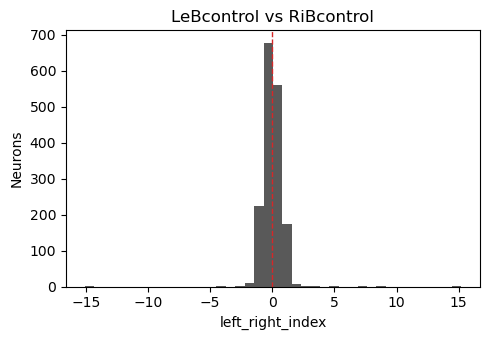

Plot stimulus labels: ['LeB1', 'LeB2', 'LeB3', 'LeB4']
Plot stimulus IDs: [3, 4, 5, 6]
Neuron filter kept 536 of 1665 neurons.


,fish_id,neuron_id,source_neuron_id,global_neuron_id,left_right_index,plot_neuron_keep
0,L684_f01,0,30,0,0.736411,True
1,L684_f01,1,31,1,1.069736,True
2,L684_f01,2,35,2,0.121111,False
3,L684_f01,3,40,3,0.790176,True
4,L684_f01,4,41,4,0.364943,True


In [317]:
# Cell 03c.2 - Notebook-level plot/filter options
# =========================
# Notebook-level plot/filter options
# =========================

# Stimuli to include in later plots.
# Set to None to keep all available stimuli.
# selected_stimuli_to_plot = None
# Example:
selected_stimuli_to_plot = [ "LeB1", "LeB2", "LeB3", "LeB4"]

# Left/right index options
compute_left_right_index = True
use_left_right_filter = True

left_right_left_stimulus = "LeBcontrol"
left_right_right_stimulus = "RiBcontrol"

left_right_threshold = 0.3
left_right_filter_mode = "left"  # options: "abs", "left", "right", "range"
left_right_min = -0.3
left_right_max = 0.3

# Diagnostics
plot_left_right_index_distribution = True
print_filter_summary = True

left_right_denominator_epsilon = 1e-12

available_auc_stimuli = list(pooled_response_matrix.columns)
if selected_stimuli_to_plot is None:
    plot_stimulus_labels = available_auc_stimuli.copy()
else:
    plot_stimulus_labels = list(selected_stimuli_to_plot)
    missing_plot_stimuli = [
        stimulus for stimulus in plot_stimulus_labels
        if stimulus not in available_auc_stimuli
    ]
    if missing_plot_stimuli:
        raise ValueError(
            "selected_stimuli_to_plot contains labels missing from pooled_response_matrix: "
            + ", ".join(missing_plot_stimuli)
        )

stimulus_label_to_id = dict(zip(response_stimulus_labels, response_stimulus_ids))
missing_plot_ids = [
    stimulus for stimulus in plot_stimulus_labels
    if stimulus not in stimulus_label_to_id
]
if missing_plot_ids:
    raise ValueError(
        "Could not map selected plot stimuli to stimulus IDs: "
        + ", ".join(missing_plot_ids)
    )
plot_stimulus_ids = [stimulus_label_to_id[stimulus] for stimulus in plot_stimulus_labels]

if pooled_response_matrix.shape[0] != response_row_metadata.shape[0]:
    raise ValueError("pooled_response_matrix rows do not match response_row_metadata rows.")

left_right_index = np.full(pooled_response_matrix.shape[0], np.nan, dtype=float)
if compute_left_right_index:
    missing_lr_stimuli = [
        stimulus for stimulus in (left_right_left_stimulus, left_right_right_stimulus)
        if stimulus not in pooled_response_matrix.columns
    ]
    if missing_lr_stimuli:
        raise ValueError(
            "Left/right index stimuli are missing from pooled_response_matrix: "
            + ", ".join(missing_lr_stimuli)
        )

    auc_left = pooled_response_matrix[left_right_left_stimulus].to_numpy(dtype=float)
    auc_right = pooled_response_matrix[left_right_right_stimulus].to_numpy(dtype=float)
    denominator = auc_left + auc_right
    finite_denominator = np.isfinite(denominator) & (np.abs(denominator) > left_right_denominator_epsilon)
    left_right_index[finite_denominator] = (
        auc_left[finite_denominator] - auc_right[finite_denominator]
    ) / denominator[finite_denominator]

plot_neuron_keep_mask = np.ones(pooled_response_matrix.shape[0], dtype=bool)
if use_left_right_filter:
    if left_right_filter_mode not in {"abs", "left", "right", "range"}:
        raise ValueError(
            "left_right_filter_mode must be one of: 'abs', 'left', 'right', 'range'."
        )
    if not compute_left_right_index:
        raise ValueError("use_left_right_filter=True requires compute_left_right_index=True.")

    if left_right_filter_mode == "abs":
        plot_neuron_keep_mask = np.isfinite(left_right_index) & (np.abs(left_right_index) >= left_right_threshold)
    elif left_right_filter_mode == "left":
        plot_neuron_keep_mask = np.isfinite(left_right_index) & (left_right_index >= left_right_threshold)
    elif left_right_filter_mode == "right":
        plot_neuron_keep_mask = np.isfinite(left_right_index) & (left_right_index <= -left_right_threshold)
    else:
        plot_neuron_keep_mask = (
            np.isfinite(left_right_index)
            & (left_right_index >= left_right_min)
            & (left_right_index <= left_right_max)
        )

plot_neuron_keep_indices = np.flatnonzero(plot_neuron_keep_mask)
plot_filter_table = response_row_metadata.copy().reset_index(drop=True)
plot_filter_table["left_right_index"] = left_right_index
plot_filter_table["plot_neuron_keep"] = plot_neuron_keep_mask
selected_auc_response_matrix = pooled_response_matrix.loc[
    plot_neuron_keep_mask,
    plot_stimulus_labels,
].copy()

# Compatibility aliases used by later notebook cells.
selected_stimulus_labels = plot_stimulus_labels
selected_stimulus_ids = plot_stimulus_ids

if plot_left_right_index_distribution and compute_left_right_index:
    fig_left_right_index_distribution, ax_left_right_index_distribution = plt.subplots(figsize=(5, 3.5))
    finite_left_right_index = left_right_index[np.isfinite(left_right_index)]
    if finite_left_right_index.size == 0:
        ax_left_right_index_distribution.text(
            0.5,
            0.5,
            "No finite left_right_index values",
            ha="center",
            va="center",
            transform=ax_left_right_index_distribution.transAxes,
        )
    else:
        ax_left_right_index_distribution.hist(finite_left_right_index, bins=40, color="0.35")
        ax_left_right_index_distribution.axvline(0, color="tab:red", linestyle="--", linewidth=1.0)
        ax_left_right_index_distribution.set_xlabel("left_right_index")
        ax_left_right_index_distribution.set_ylabel("Neurons")
    ax_left_right_index_distribution.set_title(
        f"{left_right_left_stimulus} vs {left_right_right_stimulus}"
    )
    plt.tight_layout()
    plt.show()

if print_filter_summary:
    print("Plot stimulus labels:", plot_stimulus_labels)
    print("Plot stimulus IDs:", plot_stimulus_ids)
    print(
        "Neuron filter kept "
        f"{plot_neuron_keep_indices.size} of {plot_neuron_keep_mask.shape[0]} neurons."
    )
    display(plot_filter_table.head())


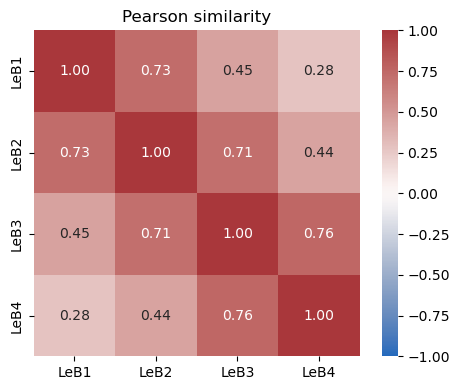

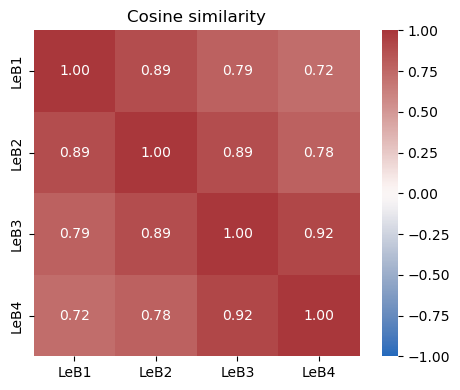

All-NaN neurons removed before clustering: 0


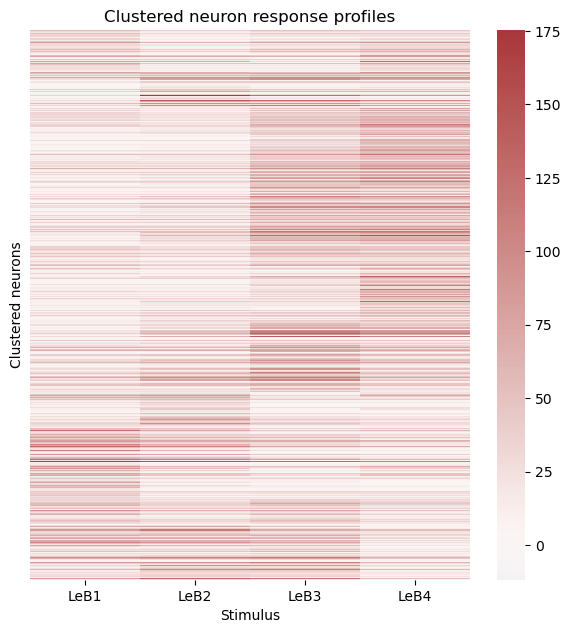

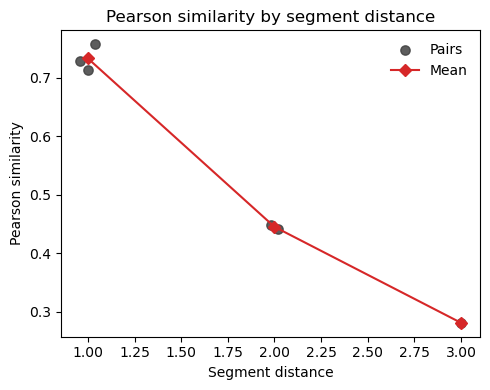

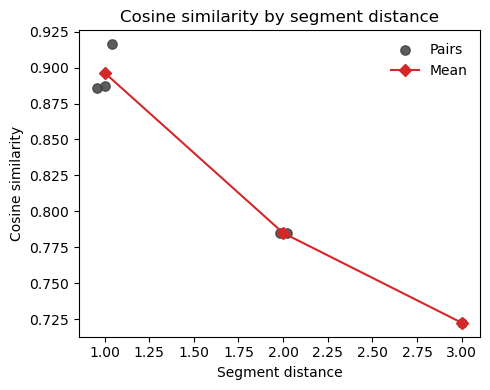

Similarity plot stimuli: ['LeB1', 'LeB2', 'LeB3', 'LeB4']
response_matrix shape: (536, 4)
selected_response_matrix shape: (536, 4)
Number of neurons: 536
Number of selected stimuli: 4


,LeB1,LeB2,LeB3,LeB4
global_neuron_id,,,,
0,71.388255,51.205163,24.436022,13.711759
1,31.918135,20.210490,46.442256,76.376905
3,48.757447,44.651657,67.482853,61.436285
4,24.142405,22.276523,28.188787,10.163760
5,36.833511,32.527108,54.380965,65.057700


,LeB1,LeB2,LeB3,LeB4
LeB1,1.000000,0.729500,0.448952,0.280832
LeB2,0.729500,1.000000,0.712949,0.441255
LeB3,0.448952,0.712949,1.000000,0.757572
LeB4,0.280832,0.441255,0.757572,1.000000


,LeB1,LeB2,LeB3,LeB4
LeB1,1.000000,0.885777,0.785182,0.722470
LeB2,0.885777,1.000000,0.887370,0.784749
LeB3,0.785182,0.887370,1.000000,0.916244
LeB4,0.722470,0.784749,0.916244,1.000000


,stimulus_a,stimulus_b,segment_distance,pearson_similarity,cosine_similarity
0,LeB1,LeB2,1,0.729500,0.885777
1,LeB1,LeB3,2,0.448952,0.785182
2,LeB1,LeB4,3,0.280832,0.722470
3,LeB2,LeB3,1,0.712949,0.887370
4,LeB2,LeB4,2,0.441255,0.784749
5,LeB3,LeB4,1,0.757572,0.916244


In [318]:
# Cell 03c.1 - Stimulus vector similarity from z-score AUC responses
# Reuses selected_auc_response_matrix from Cell 03c.2; AUC is not recomputed here.

if "selected_auc_response_matrix" in globals():
    response_matrix = selected_auc_response_matrix.copy()
    similarity_plot_stimuli = list(plot_stimulus_labels)
else:
    response_matrix = pooled_response_matrix.copy()
    similarity_plot_stimuli = list(response_matrix.columns)

missing_similarity_stimuli = [
    stimulus for stimulus in similarity_plot_stimuli
    if stimulus not in response_matrix.columns
]
if missing_similarity_stimuli:
    raise ValueError(
        "similarity_plot_stimuli contains stimulus labels missing from pooled_response_matrix: "
        + ", ".join(missing_similarity_stimuli)
    )
selected_response_matrix = response_matrix[similarity_plot_stimuli]

pearson_similarity_matrix = selected_response_matrix.corr(method="pearson")

cosine_similarity_matrix = pd.DataFrame(
    np.nan,
    index=similarity_plot_stimuli,
    columns=similarity_plot_stimuli,
    dtype=float,
)
for stimulus_a in similarity_plot_stimuli:
    vector_a = selected_response_matrix[stimulus_a].to_numpy(dtype=float)
    for stimulus_b in similarity_plot_stimuli:
        vector_b = selected_response_matrix[stimulus_b].to_numpy(dtype=float)
        finite_mask = np.isfinite(vector_a) & np.isfinite(vector_b)
        if not np.any(finite_mask):
            continue
        a = vector_a[finite_mask]
        b = vector_b[finite_mask]
        denominator = np.linalg.norm(a) * np.linalg.norm(b)
        if denominator > 0:
            cosine_similarity_matrix.loc[stimulus_a, stimulus_b] = np.dot(a, b) / denominator

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    pearson_similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Pearson similarity")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cosine_similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Cosine similarity")
plt.tight_layout()
plt.show()

all_nan_neuron_mask = selected_response_matrix.isna().all(axis=1)
n_all_nan_neurons_removed = int(all_nan_neuron_mask.sum())
print("All-NaN neurons removed before clustering:", n_all_nan_neurons_removed)

cluster_input_matrix = selected_response_matrix.loc[~all_nan_neuron_mask].copy()
if cluster_input_matrix.shape[0] <= 1:
    clustered_response_matrix = cluster_input_matrix.copy()
else:
    cluster_fill_values = cluster_input_matrix.median(axis=0, skipna=True).fillna(0.0)
    cluster_values = cluster_input_matrix.fillna(cluster_fill_values).to_numpy(dtype=float)
    cluster_distances = pdist(cluster_values, metric="correlation")
    cluster_distances = np.where(np.isfinite(cluster_distances), cluster_distances, 1.0)
    linkage_matrix = linkage(cluster_distances, method="average")
    neuron_order = leaves_list(linkage_matrix)
    clustered_response_matrix = cluster_input_matrix.iloc[neuron_order]

fig, ax = plt.subplots(figsize=(6, max(4, min(14, clustered_response_matrix.shape[0] * 0.012))))
if clustered_response_matrix.empty:
    ax.text(0.5, 0.5, "No neurons to cluster", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
else:
    sns.heatmap(
        clustered_response_matrix,
        cmap="vlag",
        center=0,
        xticklabels=True,
        yticklabels=False,
        ax=ax,
    )
    ax.set_xlabel("Stimulus")
    ax.set_ylabel("Clustered neurons")
    ax.set_title("Clustered neuron response profiles")
plt.tight_layout()
plt.show()

segment_similarity_rows = []
for index_a, stimulus_a in enumerate(similarity_plot_stimuli):
    for index_b in range(index_a + 1, len(similarity_plot_stimuli)):
        stimulus_b = similarity_plot_stimuli[index_b]
        segment_similarity_rows.append(
            {
                "stimulus_a": stimulus_a,
                "stimulus_b": stimulus_b,
                "segment_distance": abs(index_b - index_a),
                "pearson_similarity": pearson_similarity_matrix.loc[stimulus_a, stimulus_b],
                "cosine_similarity": cosine_similarity_matrix.loc[stimulus_a, stimulus_b],
            }
        )
segment_similarity_df = pd.DataFrame(
    segment_similarity_rows,
    columns=[
        "stimulus_a",
        "stimulus_b",
        "segment_distance",
        "pearson_similarity",
        "cosine_similarity",
    ],
)

for similarity_column, ylabel, title in [
    ("pearson_similarity", "Pearson similarity", "Pearson similarity by segment distance"),
    ("cosine_similarity", "Cosine similarity", "Cosine similarity by segment distance"),
]:
    fig, ax = plt.subplots(figsize=(5, 4))
    pair_plot_df = segment_similarity_df.dropna(subset=[similarity_column]).copy()
    if not pair_plot_df.empty:
        pair_offsets = pair_plot_df.groupby("segment_distance").cumcount()
        pair_counts = pair_plot_df.groupby("segment_distance")[similarity_column].transform("size")
        pair_jitter = (pair_offsets - (pair_counts - 1) / 2.0) * 0.04
        ax.scatter(
            pair_plot_df["segment_distance"] + pair_jitter,
            pair_plot_df[similarity_column],
            color="0.25",
            s=45,
            alpha=0.85,
            label="Pairs",
        )
    distance_means = pair_plot_df.groupby("segment_distance", as_index=False)[similarity_column].mean()
    if not distance_means.empty:
        ax.plot(
            distance_means["segment_distance"],
            distance_means[similarity_column],
            marker="D",
            color="tab:red",
            linewidth=1.5,
            label="Mean",
        )
        ax.legend(frameon=False)
    ax.set_xlabel("Segment distance")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

print("Similarity plot stimuli:", similarity_plot_stimuli)
print("response_matrix shape:", response_matrix.shape)
print("selected_response_matrix shape:", selected_response_matrix.shape)
print("Number of neurons:", selected_response_matrix.shape[0])
print("Number of selected stimuli:", selected_response_matrix.shape[1])

display(response_matrix.head())
display(pearson_similarity_matrix)
display(cosine_similarity_matrix)
display(segment_similarity_df)


In [319]:
# Cell 03d - Stimulus specificity slice 3 summary table scaffold
# Joins z-score response AUCs with binary active decisions and neuron identity columns.

stimulus_specificity_active_matrices = build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=selected_stimulus_ids,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    motion_onset_s=motion_onset_s,
    tau_s=tau_s,
    motion_duration_key=motion_duration_key,
)

stimulus_specificity_summary_table = build_neuron_stimulus_summary_table(
    response_matrices=response_matrices_by_fish,
    active_matrices=stimulus_specificity_active_matrices,
    row_metadata=response_row_metadata,
    selected_stimulus_ids=selected_stimulus_ids,
    selected_stimulus_labels=selected_stimulus_labels,
    analysis_label=analysis_label,
)

expected_response_columns = [f"response_{label}" for label in selected_stimulus_labels]
expected_active_columns = [f"active_{label}" for label in selected_stimulus_labels]
missing_summary_columns = [
    column
    for column in expected_response_columns + expected_active_columns
    if column not in stimulus_specificity_summary_table.columns
]
if missing_summary_columns:
    raise ValueError(f"Summary table is missing columns: {missing_summary_columns}")
if stimulus_specificity_summary_table.shape[0] != pooled_response_matrix.shape[0]:
    raise ValueError("Summary table rows do not match pooled response matrix rows.")

stimulus_specificity_unfiltered_summary_table = stimulus_specificity_summary_table.copy()

if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != stimulus_specificity_summary_table.shape[0]:
        raise ValueError(
            "plot_neuron_keep_mask length does not match stimulus_specificity_summary_table rows."
        )
    stimulus_specificity_summary_table = stimulus_specificity_summary_table.loc[
        plot_neuron_keep_mask
    ].reset_index(drop=True)

print("Stimulus specificity summary table:", stimulus_specificity_summary_table.shape)
# display(stimulus_specificity_summary_table.head())


Stimulus specificity summary table: (536, 14)


In [320]:
# Cell 03e - Stimulus specificity slice 4 selectivity metrics
# Adds raw-response preference, non-negative selectivity, and binary breadth metrics.

stimulus_specificity_metric_table = add_selectivity_metrics_to_summary_table(
    stimulus_specificity_summary_table,
    selected_stimulus_labels=selected_stimulus_labels,
)

metric_columns = [
    "preferred_stimulus",
    "max_response",
    "mean_response",
    "simple_selectivity",
    "selectivity_index",
    "lifetime_sparseness",
    "n_active_stimuli",
    "response_breadth",
]
missing_metric_columns = [
    column for column in metric_columns
    if column not in stimulus_specificity_metric_table.columns
]
if missing_metric_columns:
    raise ValueError(f"Metric table is missing columns: {missing_metric_columns}")
if stimulus_specificity_metric_table.shape[0] != stimulus_specificity_summary_table.shape[0]:
    raise ValueError("Metric table rows do not match summary table rows.")

stimulus_specificity_summary_table = stimulus_specificity_metric_table

# print("Stimulus specificity metric table:", stimulus_specificity_metric_table.shape)
# display(stimulus_specificity_metric_table[metric_columns].describe(include="all"))
# display(stimulus_specificity_metric_table.head())
stimulus_specificity_summary_table[
    ["preferred_stimulus", "max_response", "selectivity_index", "lifetime_sparseness"]
].head()

,preferred_stimulus,max_response,selectivity_index,lifetime_sparseness
0,LeB1,71.388255,0.411218,0.320492
1,LeB4,76.376905,0.398411,0.250011
2,LeB3,67.482853,0.133233,0.035902
3,LeB3,28.188787,0.198256,0.121705
4,LeB4,65.057700,0.223983,0.096236


In [321]:
# Cell 03f - Stimulus specificity slice 5 neuron classification
# Classifies neurons using configurable sparseness, breadth, and adaptive response-strength thresholds.

(
    stimulus_specificity_classified_table,
    stimulus_specificity_classification_thresholds,
) = classify_stimulus_specificity_summary_table(
    stimulus_specificity_summary_table,
    selected_stimulus_labels=selected_stimulus_labels,
    classification_thresholds=classification_thresholds,
    return_thresholds=True,
)

if "neuron_class" not in stimulus_specificity_classified_table.columns:
    raise ValueError("Classified table is missing neuron_class.")
if stimulus_specificity_classified_table.shape[0] != stimulus_specificity_summary_table.shape[0]:
    raise ValueError("Classified table rows do not match metric table rows.")

stimulus_specificity_summary_table = stimulus_specificity_classified_table

class_counts = (
    stimulus_specificity_classified_table["neuron_class"]
    .value_counts()
    .rename_axis("neuron_class")
    .reset_index(name="n_neurons")
)
threshold_table = pd.DataFrame(
    [
        {"threshold": key, "value": value}
        for key, value in stimulus_specificity_classification_thresholds.items()
    ]
)

print("Stimulus specificity classified table:", stimulus_specificity_classified_table.shape)
# display(threshold_table)
# display(class_counts)
# display(stimulus_specificity_classified_table.head())


Stimulus specificity classified table: (536, 23)


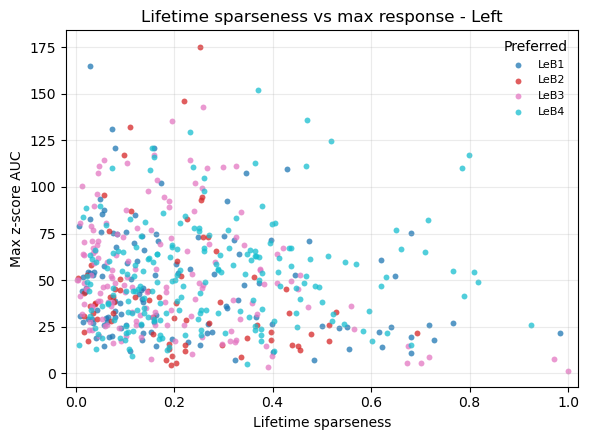

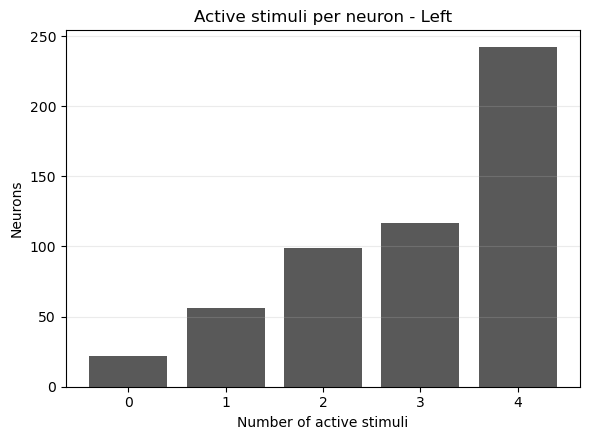

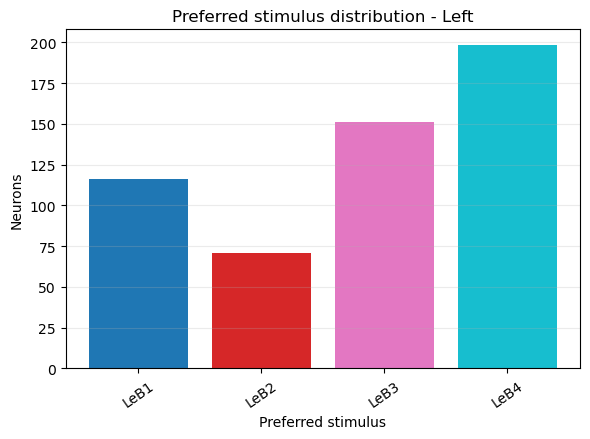

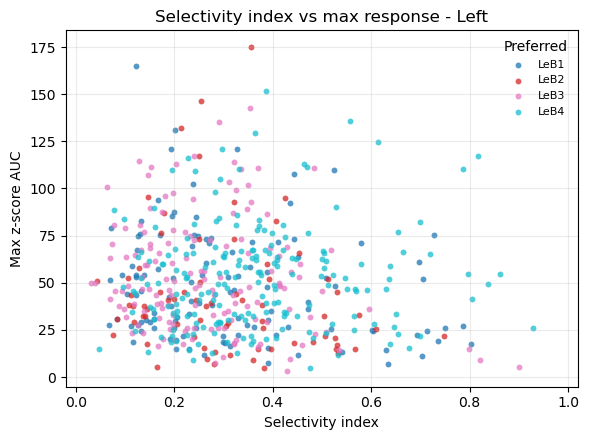

In [322]:
# Cell 03g - Stimulus specificity slice 6 summary plots
# Plots sparseness/selectivity vs response strength, active-stimuli counts, and preferred-stimulus distribution as separate figures.

fig_stimulus_specificity_sparseness, ax_stimulus_specificity_sparseness = plt.subplots(figsize=(6, 4.5))
plott.plot_stimulus_specificity_sparseness(
    stimulus_specificity_summary_table,
    selected_stimulus_labels=selected_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_stimulus_specificity_sparseness,
)
fig_stimulus_specificity_sparseness.tight_layout()
plt.show()

fig_active_stimuli_histogram, ax_active_stimuli_histogram = plt.subplots(figsize=(6, 4.5))
plott.plot_active_stimuli_histogram(
    stimulus_specificity_summary_table,
    selected_stimulus_labels=selected_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_active_stimuli_histogram,
)
fig_active_stimuli_histogram.tight_layout()
plt.show()

fig_preferred_stimulus_distribution, ax_preferred_stimulus_distribution = plt.subplots(figsize=(6, 4.5))
plott.plot_preferred_stimulus_distribution(
    stimulus_specificity_summary_table,
    selected_stimulus_labels=selected_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_preferred_stimulus_distribution,
)
fig_preferred_stimulus_distribution.tight_layout()
plt.show()

fig_stimulus_specificity_selectivity_index, ax_stimulus_specificity_selectivity_index = plt.subplots(figsize=(6, 4.5))
plott.plot_stimulus_specificity_selectivity_index(
    stimulus_specificity_summary_table,
    selected_stimulus_labels=selected_stimulus_labels,
    analysis_label=analysis_label,
    ax=ax_stimulus_specificity_selectivity_index,
)
fig_stimulus_specificity_selectivity_index.tight_layout()
plt.show()


## Cell 04a - Segment selectivity permutations
Builds per-trial AUC responses for B1-B4 and tests neuron-wise segment selectivity by label shuffling.


In [323]:
# Cell 04a - Segment selectivity permutation analysis
# Builds trial-level z-score AUC responses and tests segment selectivity with neuron-wise label shuffles.

# OPTIONS
segments_to_compare = ["B1", "B2", "B3", "B4"]
n_permutations = 1000
random_seed = 42
alpha_percentile = 95

rng = np.random.default_rng(random_seed)
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz


def resolve_segment_labels(segments, available_labels):
    """Resolve editable segment names against selected stimulus labels."""
    resolved = []
    for segment in segments:
        exact_matches = [label for label in available_labels if label == segment]
        if len(exact_matches) == 1:
            resolved.append(exact_matches[0])
            continue

        suffix_matches = [label for label in available_labels if str(label).endswith(str(segment))]
        if len(suffix_matches) == 1:
            resolved.append(suffix_matches[0])
        elif len(suffix_matches) == 0:
            raise KeyError(
                f"Segment {segment!r} was not found in selected stimulus labels "
                f"{available_labels!r}."
            )
        else:
            raise ValueError(
                f"Segment {segment!r} matched multiple selected stimulus labels: "
                f"{suffix_matches!r}. Use an exact label."
            )

    if len(set(resolved)) != len(resolved):
        raise ValueError(f"Resolved segment labels are not unique: {resolved!r}")
    return resolved


def compute_trial_auc_by_neuron(trial_aligned_trace, frame_indices, time_s=None, fps_2p=None):
    """Return per-neuron, per-trial AUC values with shape (n_neurons, n_reps)."""
    arr = np.asarray(trial_aligned_trace, dtype=float)
    if arr.ndim != 3:
        raise ValueError(
            f"trial_aligned_trace has shape {arr.shape}; expected "
            "(n_neurons, n_time, n_reps)."
        )

    frame_indices = np.asarray(frame_indices, dtype=int).ravel()
    if frame_indices.size == 0:
        raise ValueError("frame_indices must contain at least one frame.")
    if np.any(frame_indices < 0) or np.any(frame_indices >= arr.shape[1]):
        raise IndexError(
            "frame_indices are outside the trace time axis "
            f"with n_time={arr.shape[1]}."
        )

    response = arr[:, frame_indices, :]
    if time_s is not None:
        time_s = np.asarray(time_s, dtype=float)
        if time_s.ndim != 1 or time_s.shape[0] != arr.shape[1]:
            raise ValueError("time_s must be 1D with one value per trace frame.")
        x = time_s[frame_indices]
        if x.size == 1:
            if fps_2p is None:
                raise ValueError("fps_2p is required for single-frame AUC windows.")
            return response[:, 0, :] / float(fps_2p)
        return trapz(response, x=x, axis=1)

    if fps_2p is None:
        raise ValueError("Either time_s or fps_2p is required.")
    if frame_indices.size == 1:
        return response[:, 0, :] / float(fps_2p)
    return trapz(response, dx=1.0 / float(fps_2p), axis=1)


def compute_selectivity_index(segment_to_trials):
    """Compute preferred segment and SI from a dict of segment -> trial values."""
    means = {}
    for segment, values in segment_to_trials.items():
        values = np.asarray(values, dtype=float).ravel()
        finite_values = values[np.isfinite(values)]
        if finite_values.size == 0:
            return np.nan, np.nan, "missing_or_empty_trials"
        means[segment] = float(np.mean(finite_values))

    mean_values = np.asarray(list(means.values()), dtype=float)
    if not np.all(np.isfinite(mean_values)):
        return np.nan, np.nan, "invalid_segment_mean"

    preferred_idx = int(np.argmax(mean_values))
    preferred = list(means.keys())[preferred_idx]
    r_preferred = mean_values[preferred_idx]
    r_others = float(np.mean(np.delete(mean_values, preferred_idx)))
    denominator = r_preferred + r_others
    if r_preferred <= 0.0 or r_others < 0.0:
        return np.nan, preferred, "negative_or_nonpositive_response"
    if (
        not np.isfinite(denominator)
        or denominator <= 0.0
        or np.isclose(denominator, 0.0)
    ):
        return np.nan, preferred, "zero_or_invalid_denominator"

    si = float((r_preferred - r_others) / denominator)
    return si, preferred, None


def shuffle_segment_trials(segment_to_trials, rng):
    """Shuffle pooled trial values back into segments while preserving counts."""
    segment_counts = {
        segment: np.asarray(values, dtype=float).ravel().size
        for segment, values in segment_to_trials.items()
    }
    pooled = np.concatenate(
        [np.asarray(values, dtype=float).ravel() for values in segment_to_trials.values()]
    )
    shuffled = rng.permutation(pooled)

    shuffled_segments = {}
    start = 0
    for segment, count in segment_counts.items():
        stop = start + count
        shuffled_segments[segment] = shuffled[start:stop]
        start = stop
    return shuffled_segments


def run_segment_selectivity_permutations(neuron_segment_trials, n_permutations, rng):
    """Run real and shuffled selectivity calculations for one neuron."""
    real_si, real_preferred, skip_reason = compute_selectivity_index(neuron_segment_trials)
    shuffled_si = np.full(int(n_permutations), np.nan, dtype=float)
    if skip_reason is not None:
        return real_si, real_preferred, shuffled_si, skip_reason

    for perm_idx in range(int(n_permutations)):
        shuffled_trials = shuffle_segment_trials(neuron_segment_trials, rng)
        shuffled_si[perm_idx], _, _ = compute_selectivity_index(shuffled_trials)
    return real_si, real_preferred, shuffled_si, None


segment_source_labels = list(selected_stimulus_labels)
resolved_segment_labels = resolve_segment_labels(segments_to_compare, segment_source_labels)
segment_display_labels = list(segments_to_compare)
segment_label_to_display = dict(zip(resolved_segment_labels, segment_display_labels))

selected_label_to_id = dict(zip(selected_stimulus_labels, selected_stimulus_ids))
segment_label_to_id = {
    label: selected_label_to_id[label]
    for label in resolved_segment_labels
}

trial_auc_by_fish = {}
trial_count_rows = []
warning_rows = []

for fid in fish_ids:
    fish = all_fish_data[fid]
    trial_aligned_z = fish["trial_aligned_traces_z_core"]
    kept_idx = np.asarray(fish["kept_neuron_indices"], dtype=int).ravel()
    if kept_idx.size == 0:
        raise ValueError(f"Fish {fid!r} has empty kept_neuron_indices.")

    trial_auc_by_fish[fid] = {}
    n_kept_expected = None
    fish_trial_counts = []

    for resolved_label in resolved_segment_labels:
        display_label = segment_label_to_display[resolved_label]
        stim_id = segment_label_to_id[resolved_label]
        stim_key = stim_id if stim_id in trial_aligned_z else str(stim_id)
        if stim_key not in trial_aligned_z:
            raise KeyError(
                f"Fish {fid!r} is missing stimulus {resolved_label!r} "
                f"(ID {stim_id!r}) in trial_aligned_traces_z_core."
            )

        arr = np.asarray(trial_aligned_z[stim_key], dtype=float)
        if arr.ndim != 3:
            raise ValueError(
                f"Fish {fid!r}, segment {resolved_label!r} has shape {arr.shape}; "
                "expected (n_neurons, n_time, n_reps)."
            )
        if np.any(kept_idx < 0) or np.any(kept_idx >= arr.shape[0]):
            raise IndexError(
                f"Fish {fid!r} kept_neuron_indices contains values outside "
                f"segment {resolved_label!r} neuron axis with n_neurons={arr.shape[0]}."
            )

        arr_kept = arr[kept_idx, :, :]
        if n_kept_expected is None:
            n_kept_expected = arr_kept.shape[0]
        elif arr_kept.shape[0] != n_kept_expected:
            raise ValueError(
                f"Fish {fid!r}, segment {resolved_label!r} has {arr_kept.shape[0]} "
                f"kept neurons; expected {n_kept_expected}."
            )

        if arr_kept.shape[2] == 0:
            warning_rows.append(
                {
                    "fish_id": fid,
                    "segment": display_label,
                    "warning": "empty_response_array",
                }
            )

        window = at.compute_response_window_frames(
            n_time=arr_kept.shape[1],
            fps_2p=fps_2p,
            t_pre_s=t_pre_s,
            motion_onset_s=motion_onset_s,
            stimulus=stim_id,
            stimuli_durations=fish["stimuli_durations"],
            stimuli_id_map=fish["stimuli_id_map"],
            tau_s=tau_s,
            motion_duration_key=motion_duration_key,
        )
        trial_auc_by_fish[fid][display_label] = compute_trial_auc_by_neuron(
            arr_kept,
            frame_indices=window["frame_indices"],
            time_s=window["time_s"],
            fps_2p=fps_2p,
        )
        fish_trial_counts.append(arr_kept.shape[2])
        trial_count_rows.append(
            {
                "fish_id": fid,
                "segment": display_label,
                "resolved_label": resolved_label,
                "stimulus_id": stim_id,
                "n_kept_neurons": arr_kept.shape[0],
                "n_trials": arr_kept.shape[2],
                "n_response_frames": window["n_frames"],
                "start_frame": window["start_frame"],
                "stop_frame": window["stop_frame"],
            }
        )

    unique_trial_counts = set(fish_trial_counts)
    if len(unique_trial_counts) > 1:
        warning_rows.append(
            {
                "fish_id": fid,
                "segment": "all",
                "warning": f"unequal_trial_counts:{fish_trial_counts}",
            }
        )

summary_rows = []
si_shuffle_rows = []
global_row = 0
skip_reason_counts = {}

for fid in fish_ids:
    fish = all_fish_data[fid]
    kept_idx = np.asarray(fish["kept_neuron_indices"], dtype=int).ravel()
    n_kept = kept_idx.size

    for neuron_id in range(n_kept):
        neuron_segment_trials = {
            segment: trial_auc_by_fish[fid][segment][neuron_id, :]
            for segment in segment_display_labels
        }
        real_si, real_preferred, shuffled_si, skip_reason = run_segment_selectivity_permutations(
            neuron_segment_trials,
            n_permutations=n_permutations,
            rng=rng,
        )
        if skip_reason is not None:
            skip_reason_counts[skip_reason] = skip_reason_counts.get(skip_reason, 0) + 1

        finite_shuffle = shuffled_si[np.isfinite(shuffled_si)]
        if finite_shuffle.size == 0:
            threshold = np.nan
            is_significant = False
        else:
            threshold = float(np.nanpercentile(finite_shuffle, alpha_percentile))
            is_significant = bool(np.isfinite(real_si) and real_si > threshold)

        summary_rows.append(
            {
                "fish_id": fid,
                "neuron_id": neuron_id,
                "kept_neuron_index": int(kept_idx[neuron_id]),
                "global_neuron_id": global_row,
                "SIreal": real_si,
                "preferred_segment": real_preferred,
                "shuffle_percentile_threshold": threshold,
                "significant": is_significant,
                "skip_reason": skip_reason,
            }
        )
        si_shuffle_rows.append(shuffled_si)
        global_row += 1

segment_selectivity_summary_df = pd.DataFrame(summary_rows)
si_real = segment_selectivity_summary_df["SIreal"].to_numpy(dtype=float)
si_shuffle = np.vstack(si_shuffle_rows) if si_shuffle_rows else np.empty((0, int(n_permutations)))
preferred_segment = segment_selectivity_summary_df["preferred_segment"].to_numpy(dtype=object)
significant_segment_selective = segment_selectivity_summary_df["significant"].to_numpy(dtype=bool)
segment_selectivity_trial_counts_df = pd.DataFrame(trial_count_rows)
segment_selectivity_warnings_df = pd.DataFrame(warning_rows)

segment_selectivity_results = {
    "segments_requested": segment_display_labels,
    "segments_resolved": resolved_segment_labels,
    "segment_label_to_id": segment_label_to_id,
    "trial_auc_by_fish": trial_auc_by_fish,
    "trial_counts": segment_selectivity_trial_counts_df,
    "warnings": segment_selectivity_warnings_df,
    "summary_df": segment_selectivity_summary_df,
    "si_real": si_real,
    "si_shuffle": si_shuffle,
    "preferred_segment": preferred_segment,
    "significant_segment_selective": significant_segment_selective,
    "skip_reason_counts": skip_reason_counts,
    "alpha_percentile": alpha_percentile,
    "n_permutations": n_permutations,
    "random_seed": random_seed,
}

n_analyzed = int(np.count_nonzero(np.isfinite(si_real)))
n_skipped = int(segment_selectivity_summary_df["skip_reason"].notna().sum())
significant_counts = (
    segment_selectivity_summary_df.loc[significant_segment_selective, "preferred_segment"]
    .value_counts()
    .reindex(segment_display_labels, fill_value=0)
)

print("Neurons analyzed:", n_analyzed)
print("Segments used:", segment_display_labels)
print("Resolved stimulus labels:", resolved_segment_labels)
print("Number of permutations:", n_permutations)
print("Significant selective neurons:", int(np.count_nonzero(significant_segment_selective)))
print("Significant neurons per preferred segment:")
print(significant_counts)
print("Neurons skipped because of NaN or missing data:", n_skipped)
if skip_reason_counts:
    print("Skip reasons:", skip_reason_counts)
if not segment_selectivity_warnings_df.empty:
    print("Warnings:")
    display(segment_selectivity_warnings_df)

display(segment_selectivity_trial_counts_df)
display(segment_selectivity_summary_df.head())


Neurons analyzed: 1487
Segments used: ['B1', 'B2', 'B3', 'B4']
Resolved stimulus labels: ['LeB1', 'LeB2', 'LeB3', 'LeB4']
Number of permutations: 1000
Significant selective neurons: 361
Significant neurons per preferred segment:
preferred_segment
B1    137
B2     42
B3     57
B4    125
Name: count, dtype: int64
Neurons skipped because of NaN or missing data: 178
Skip reasons: {'negative_or_nonpositive_response': 178}


,fish_id,segment,resolved_label,stimulus_id,n_kept_neurons,n_trials,n_response_frames,start_frame,stop_frame
0,L684_f01,B1,LeB1,3,254,4,28,26,54
1,L684_f01,B2,LeB2,4,254,4,28,26,54
2,L684_f01,B3,LeB3,5,254,4,28,26,54
3,L684_f01,B4,LeB4,6,254,4,28,26,54
4,L684_f07,B1,LeB1,3,163,4,28,26,54
5,L684_f07,B2,LeB2,4,163,4,28,26,54
6,L684_f07,B3,LeB3,5,163,4,28,26,54
7,L684_f07,B4,LeB4,6,163,4,28,26,54
8,L733_f01,B1,LeB1,3,353,4,28,26,54
9,L733_f01,B2,LeB2,4,353,4,28,26,54


,fish_id,neuron_id,kept_neuron_index,global_neuron_id,SIreal,preferred_segment,shuffle_percentile_threshold,significant,skip_reason
0,L684_f01,0,30,0,0.411218,B1,0.643696,False,None
1,L684_f01,1,31,1,0.398411,B4,0.353166,True,None
2,L684_f01,2,35,2,0.419072,B1,0.399902,True,None
3,L684_f01,3,40,3,0.133233,B3,0.176916,False,None
4,L684_f01,4,41,4,0.198256,B3,0.278789,False,None


## Cell 04b - Segment selectivity plot
Plots real selectivity values against the pooled shuffled SI distribution; significance remains neuron-specific.


Neurons analyzed: 1487
Segments used: ['B1', 'B2', 'B3', 'B4']
Number of permutations: 1000
Significant selective neurons: 361
Significant neurons per preferred segment:
preferred_segment
B1    137
B2     42
B3     57
B4    125
Name: count, dtype: int64
Neurons skipped because of NaN or missing data: 178
Skip reasons: {'negative_or_nonpositive_response': 178}


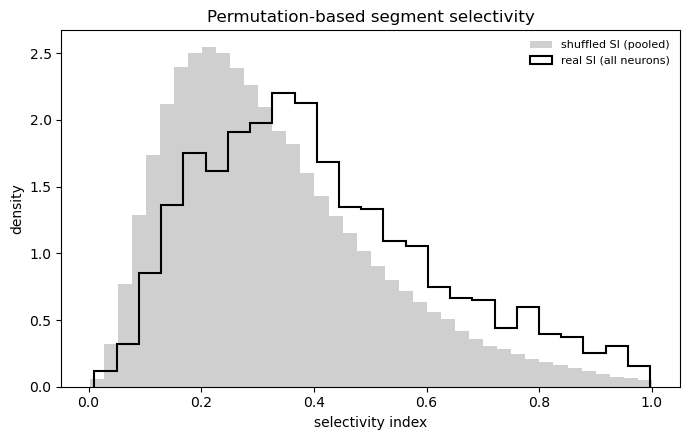

In [324]:
# Cell 04b - Segment selectivity permutation plots
# Visualizes the real SI distribution against the pooled shuffled SI distribution.

finite_shuffle = si_shuffle[np.isfinite(si_shuffle)]
finite_real = si_real[np.isfinite(si_real)]

print("Neurons analyzed:", int(np.count_nonzero(np.isfinite(si_real))))
print("Segments used:", segment_selectivity_results["segments_requested"])
print("Number of permutations:", segment_selectivity_results["n_permutations"])
print("Significant selective neurons:", int(np.count_nonzero(significant_segment_selective)))
print("Significant neurons per preferred segment:")
print(
    segment_selectivity_summary_df.loc[significant_segment_selective, "preferred_segment"]
    .value_counts()
    .reindex(segment_selectivity_results["segments_requested"], fill_value=0)
)
print(
    "Neurons skipped because of NaN or missing data:",
    int(segment_selectivity_summary_df["skip_reason"].notna().sum()),
)
if segment_selectivity_results["skip_reason_counts"]:
    print("Skip reasons:", segment_selectivity_results["skip_reason_counts"])
if not segment_selectivity_warnings_df.empty:
    print("Warnings:")
    display(segment_selectivity_warnings_df)

fig_segment_si, ax_segment_si = plt.subplots(figsize=(7, 4.5))

if finite_shuffle.size > 0:
    ax_segment_si.hist(
        finite_shuffle,
        bins=40,
        color="0.75",
        alpha=0.75,
        density=True,
        label="shuffled SI (pooled)",
    )
if finite_real.size > 0:
    ax_segment_si.hist(
        finite_real,
        bins=25,
        histtype="step",
        color="black",
        linewidth=1.5,
        density=True,
        label="real SI (all neurons)",
    )

ax_segment_si.set_xlabel("selectivity index")
ax_segment_si.set_ylabel("density")
ax_segment_si.set_title("Permutation-based segment selectivity")
ax_segment_si.legend(frameon=False, fontsize=8)
fig_segment_si.tight_layout()
plt.show()


## Cell 05 - Style notes
Markdown separator before stimulus styling configuration.


In [325]:
# Cell 06 - Stimulus styles
# Defines colors, line styles, display order, and peri-stimulus plotting windows.
# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'FlickL': sns.color_palette('dark:#404040', 10)[7],
    'FlickR': sns.color_palette('dark:#404040', 10)[7],
    'LeB1': sns.color_palette('Blues', 8)[7],
    'LeB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'LeB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'RiB1': sns.color_palette('Blues', 8)[7],
    'RiB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'RiB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'LeB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'RiB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'LeBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RiBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RockL': sns.color_palette('PuRd', as_cmap=True)(0.6),
    'RockR': sns.color_palette('PuRd', as_cmap=True)(0.6),
}
linestyles_C = {
    'FlickR': '--',
    'RiB1': '--',
    'RiB2': '--',
    'RiB3': '--',
    'RiB4': '--',
    'RiBcontrol': '--',
    'RockR': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = [
    'LeBcontrol',
    'RiBcontrol',
    'LeB1',
    'LeB2',
    'LeB3',
    'LeB4',
    'RiB1',
    'RiB2',
    'RiB3',
    'RiB4',
    'RockL',
    'RockR',
    'FlickL',
    'FlickR'
]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_5_map_positions
{'FlickR': '--', 'RiB1': '--', 'RiB2': '--', 'RiB3': '--', 'RiB4': '--', 'RiBcontrol': '--', 'RockR': '--'}


In [326]:
# Cell 07 - Matrix builders
# Combines stimulus repetitions and stacks selected traces across all fish into one analysis matrix.
def combine_reps_one_stim(arr, mode="concat"):
    """
    arr: (n_neurons, n_time, n_reps)
    mode: "concat" or "mean"

    Returns:
        if mode == "concat": (n_neurons, n_time * n_reps)
        if mode == "mean":   (n_neurons, n_time)
    """
    assert arr.ndim == 3, "Expected 3D array (neurons, time, reps)"
    n_neurons, n_time, n_reps = arr.shape

    if mode == "concat":
        # (N, T, R) -> (N, R, T) -> (N, R*T)
        arr_swapped = np.swapaxes(arr, 1, 2)          # (n_neurons, n_reps, n_time)
        out = arr_swapped.reshape(n_neurons, n_reps * n_time)
        return out

    elif mode == "mean":
        # average across reps axis
        out = np.nanmean(arr, axis=2)                 # (n_neurons, n_time)
        return out

    else:
        raise ValueError(f"Unknown mode '{mode}', use 'concat' or 'mean'")


def build_matrix_for_fish(trial_aligned_traces,
                          stim_order,
                          kept_neuron_indices=None,
                          combine_mode="concat"):
    """
    trial_aligned_traces: dict[stim_id] -> array (neurons, time, reps)
    stim_order: list with desired stimulus order
    kept_neuron_indices: 1D array/list of neuron indices to keep, or None
    combine_mode: "concat" or "mean"
    """
    blocks = []

    for stim in stim_order:
        # Handle int vs str keys
        if stim in trial_aligned_traces:
            arr = trial_aligned_traces[stim]
        else:
            arr = trial_aligned_traces[str(stim)]

        # 🔴 HERE we apply your kept_neuron_indices
        if kept_neuron_indices is not None:
            arr = arr[kept_neuron_indices, :, :]

        arr_block = combine_reps_one_stim(arr, mode=combine_mode)  # (N, T*reps)
        blocks.append(arr_block)

    # Concatenate horizontally along time
    fish_mat = np.concatenate(blocks, axis=1)   # (N, sum_j T_j * reps_j)
    return fish_mat

def build_matrix_all_fish(
    all_fish_data,
    stim_order,
    fish_ids=None,
    combine_mode="concat",
    trace_type="dfof",
):
    """
    all_fish_data[fish_id][...] -> dict[stim] -> (neurons, time, reps)

    Parameters
    ----------
    all_fish_data : dict
        Per-fish data container.
    stim_order : list
        Stimulus order to use when building the matrix.
    fish_ids : list, optional
        Fish IDs to include. If None, use all fish in all_fish_data.
    combine_mode : str, default="concat"
        Passed to build_matrix_for_fish.
    trace_type : str, default="dfof"
        Which trace representation to use:
        - "dfof"   -> trial_aligned_traces
        - "raster" -> trial_aligned_traces_raster
        - "zscore" -> trial_aligned_traces_z_core

    Returns
    -------
    M_all : np.ndarray
        Shape (sum_neurons_all_fish, total_time)
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    mats = []
    for fid in fish_ids:

        if trace_type == "raster":
            trial_key = "trial_aligned_traces_raster"
            kept_idx = None   # already filtered for raster version

        elif trace_type == "zscore":
            trial_key = "trial_aligned_traces_z_core"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        elif trace_type == "dfof":
            trial_key = "trial_aligned_traces"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        else:
            raise ValueError(
                f"Unknown trace_type={trace_type!r}. "
                "Use 'dfof', 'raster', or 'zscore'."
            )

        trial_aligned_traces = all_fish_data[fid][trial_key]

        M_fish = build_matrix_for_fish(
            trial_aligned_traces=trial_aligned_traces,
            stim_order=stim_order,
            kept_neuron_indices=kept_idx,
            combine_mode=combine_mode,
        )
        mats.append(M_fish)

    M_all = np.vstack(mats)

    return M_all

Computed lifetime sparseness metrics for this raster cell.
Notebook-level neuron filter for Cell 08/19 kept 536 of 1665 candidate neurons before lifetime-sparseness filtering.
Neurons with lifetime sparseness > 0.75: 11
Preferred stimulus order: ['LeB1', 'LeB2', 'LeB3', 'LeB4']
Plot stimulus order: [3, 4, 5, 6]
Counts by preferred stimulus:
preferred_stimulus
LeB1    2
LeB2    0
LeB3    2
LeB4    7
Name: count, dtype: int64


,fish_id,neuron_id,source_neuron_id,global_neuron_id,preferred_stimulus,max_response,lifetime_sparseness
0,L733_f07,232,778,1487,LeB1,26.979522,0.767255
1,L733_f01,187,747,604,LeB1,21.480438,0.982715
2,L733_f07,271,891,1526,LeB3,7.860805,0.971918
3,L733_f06,484,1876,1254,LeB3,1.549441,1.000000
4,L733_f06,103,383,873,LeB4,117.103588,0.799356


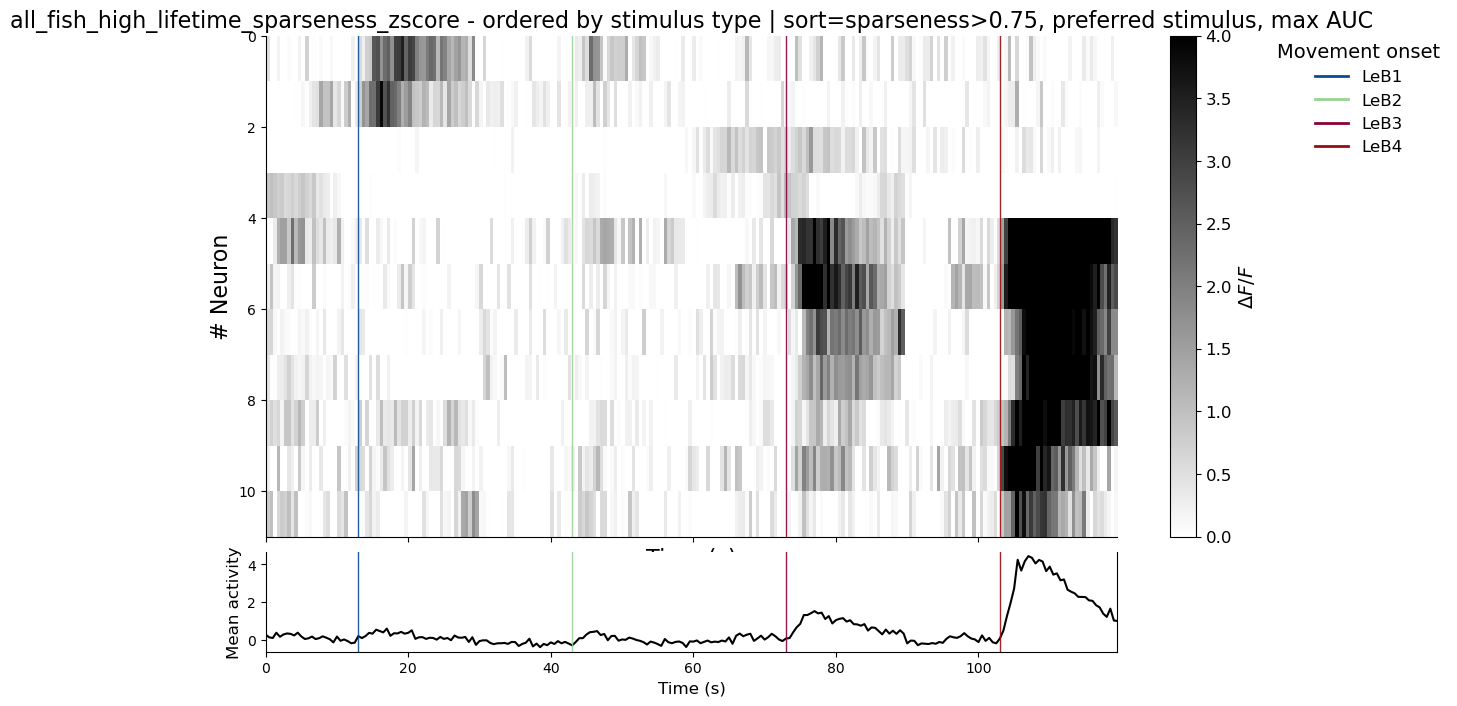

In [327]:
# Cell 08 - High lifetime-sparseness z-score raster
# Filters neurons by lifetime sparseness, orders them by preferred stimulus and max AUC, then plots z-score traces.

# OPTIONS
lifetime_sparseness_threshold = 0.75
high_sparseness_plot_stim_order = selected_stimulus_ids
high_sparseness_preferred_stimulus_order = selected_stimulus_labels
high_sparseness_combine_mode = "mean"
high_sparseness_trace_type = "zscore"

required_columns = [
    "global_neuron_id",
    "fish_id",
    "neuron_id",
    "source_neuron_id",
    "lifetime_sparseness",
    "preferred_stimulus",
    "max_response",
]

high_sparseness_metric_source_table = globals().get(
    "stimulus_specificity_unfiltered_summary_table",
    stimulus_specificity_summary_table,
).copy()
high_sparseness_source_row_count = high_sparseness_metric_source_table.shape[0]
missing_columns = [
    column for column in required_columns
    if column not in high_sparseness_metric_source_table.columns
]

if (
    missing_columns
    and "stimulus_specificity_unfiltered_summary_table" not in globals()
    and "stimulus_specificity_classified_table" in globals()
):
    candidate_table = stimulus_specificity_classified_table
    candidate_missing = [
        column for column in required_columns
        if column not in candidate_table.columns
    ]
    if not candidate_missing:
        high_sparseness_metric_source_table = candidate_table.copy()
        high_sparseness_source_row_count = high_sparseness_metric_source_table.shape[0]
        missing_columns = []
        print("Using stimulus_specificity_classified_table for lifetime sparseness metrics.")

if (
    missing_columns
    and "stimulus_specificity_unfiltered_summary_table" not in globals()
    and "stimulus_specificity_metric_table" in globals()
):
    candidate_table = stimulus_specificity_metric_table
    candidate_missing = [
        column for column in required_columns
        if column not in candidate_table.columns
    ]
    if not candidate_missing:
        high_sparseness_metric_source_table = candidate_table.copy()
        high_sparseness_source_row_count = high_sparseness_metric_source_table.shape[0]
        missing_columns = []
        print("Using stimulus_specificity_metric_table for lifetime sparseness metrics.")

if missing_columns:
    high_sparseness_metric_source_table = add_selectivity_metrics_to_summary_table(
        high_sparseness_metric_source_table,
        selected_stimulus_labels=selected_stimulus_labels,
    )
    high_sparseness_source_row_count = high_sparseness_metric_source_table.shape[0]
    missing_columns = [
        column for column in required_columns
        if column not in high_sparseness_metric_source_table.columns
    ]
    if missing_columns:
        raise ValueError(
            "Could not build lifetime-sparseness metric table; missing column(s): "
            + ", ".join(missing_columns)
        )
    print("Computed lifetime sparseness metrics for this raster cell.")

if "plot_neuron_keep_mask" in globals():
    high_sparseness_global_ids = high_sparseness_metric_source_table["global_neuron_id"].to_numpy(dtype=int)
    if plot_neuron_keep_mask.shape[0] <= high_sparseness_global_ids.max(initial=-1):
        raise ValueError(
            "plot_neuron_keep_mask is shorter than the global_neuron_id values in "
            "high_sparseness_metric_source_table."
        )
    high_sparseness_metric_source_table = high_sparseness_metric_source_table.loc[
        plot_neuron_keep_mask[high_sparseness_global_ids]
    ].copy()
    print(
        "Notebook-level neuron filter for Cell 08/19 kept "
        f"{high_sparseness_metric_source_table.shape[0]} of {high_sparseness_source_row_count} "
        "candidate neurons before lifetime-sparseness filtering."
    )

high_sparseness_response_matrix = build_matrix_all_fish(
    all_fish_data,
    high_sparseness_plot_stim_order,
    fish_ids=fish_ids,
    combine_mode=high_sparseness_combine_mode,
    trace_type=high_sparseness_trace_type,
)

if high_sparseness_response_matrix.shape[0] != high_sparseness_metric_source_table.shape[0]:
    valid_global_rows = (
        "global_neuron_id" in high_sparseness_metric_source_table.columns
        and high_sparseness_metric_source_table["global_neuron_id"].between(
            0,
            high_sparseness_response_matrix.shape[0] - 1,
        ).all()
    )
    if not valid_global_rows:
        raise ValueError(
            "Z-score matrix rows do not match the metric source table rows: "
            f"{high_sparseness_response_matrix.shape[0]} vs "
            f"{high_sparseness_metric_source_table.shape[0]}."
        )

preference_rank = {
    stimulus: rank
    for rank, stimulus in enumerate(high_sparseness_preferred_stimulus_order)
}
high_sparseness_summary_df = high_sparseness_metric_source_table.loc[
    np.isfinite(high_sparseness_metric_source_table["lifetime_sparseness"])
    & (high_sparseness_metric_source_table["lifetime_sparseness"] > lifetime_sparseness_threshold)
].copy()

high_sparseness_summary_df["_preferred_stimulus_rank"] = (
    high_sparseness_summary_df["preferred_stimulus"]
    .map(preference_rank)
    .fillna(len(preference_rank))
)
high_sparseness_summary_df["_max_auc_sort"] = high_sparseness_summary_df[
    "max_response"
].fillna(-np.inf)

high_sparseness_summary_df = high_sparseness_summary_df.sort_values(
    by=["_preferred_stimulus_rank", "_max_auc_sort", "global_neuron_id"],
    ascending=[True, False, True],
    kind="mergesort",
).reset_index(drop=True)

high_sparseness_neuron_order_global = high_sparseness_summary_df[
    "global_neuron_id"
].to_numpy(dtype=int)
high_sparseness_zscore_matrix = high_sparseness_response_matrix[
    high_sparseness_neuron_order_global,
    :,
]
high_sparseness_neuron_order = np.arange(
    high_sparseness_zscore_matrix.shape[0],
    dtype=int,
)

print(
    f"Neurons with lifetime sparseness > {lifetime_sparseness_threshold}: "
    f"{high_sparseness_zscore_matrix.shape[0]}"
)
print("Preferred stimulus order:", list(high_sparseness_preferred_stimulus_order))
print("Plot stimulus order:", list(high_sparseness_plot_stim_order))
print("Counts by preferred stimulus:")
print(
    high_sparseness_summary_df["preferred_stimulus"]
    .value_counts()
    .reindex(high_sparseness_preferred_stimulus_order, fill_value=0)
)

display(
    high_sparseness_summary_df[
        [
            "fish_id",
            "neuron_id",
            "source_neuron_id",
            "global_neuron_id",
            "preferred_stimulus",
            "max_response",
            "lifetime_sparseness",
        ]
    ].head()
)

if high_sparseness_zscore_matrix.shape[0] == 0:
    print("No neurons passed the lifetime sparseness threshold; raster was not plotted.")
    fig_high_sparseness_zscore_raster = None
    ax_high_sparseness_zscore_raster = None
    im_high_sparseness_zscore_raster = None
else:
    (
        fig_high_sparseness_zscore_raster,
        ax_high_sparseness_zscore_raster,
        im_high_sparseness_zscore_raster,
        high_sparseness_plot_order,
    ) = plott.plot_allfish_flat_raster(
        data=high_sparseness_zscore_matrix,
        trial_aligned_traces=reference_fish["trial_aligned_traces_z_core"],
        stim_order=high_sparseness_plot_stim_order,
        stimuli_id_map=reference_fish["stimuli_id_map"],
        stimuli_durations=reference_fish["stimuli_durations"],
        stimuli_colors=stimuli_colors,
        stimuli_linestyles=stimuli_linestyles,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        combine_mode=high_sparseness_combine_mode,
        sort_mode="unsorted",
        neuron_order=high_sparseness_neuron_order,
        sort_label=f"sparseness>{lifetime_sparseness_threshold}, preferred stimulus, max AUC",
        is_binary=False,
        show_mean_trace=True,
        figsize=(12, 8),
        fish_id="all_fish_high_lifetime_sparseness_zscore",
        vmax=4,
    )
    plt.show()


In [328]:
# Cell 09 - Inspect fish metadata
# Selects one fish and prints stimulus ID/duration mappings used by later plots.
fish_id = fish_ids[1]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
onsets_by_id = all_fish_data[fish_id]["onsets_by_id"]
print(stimuli_id_map)
print(stimuli_durations)

{'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}
{'FlickL': {'static_before_sec': 8.0, 'motion_sec': 1.9, 'static_after_sec': 0, 'total_sec': 9.9, 'total_frames': 594, 'motion_start_frame': 480, 'motion_end_frame': 594, 'start_frame': 480, 'end_frame': 594}, 'FlickR': {'static_before_sec': 8.0, 'motion_sec': 1.9, 'static_after_sec': 0, 'total_sec': 9.9, 'total_frames': 594, 'motion_start_frame': 480, 'motion_end_frame': 594, 'start_frame': 480, 'end_frame': 594}, 'LeB1': {'static_before_sec': 8.0, 'motion_sec': 1.883, 'static_after_sec': 0, 'total_sec': 9.883333333333333, 'total_frames': 593, 'motion_start_frame': 480, 'motion_end_frame': 593, 'start_frame': 480, 'end_frame': 593}, 'LeB2': {'static_before_sec': 8.0, 'motion_sec': 1.883, 'static_after_sec': 0, 'total_sec': 9.883333333333333, 'total_frames': 593, 'motion_start_frame': 480, 'motion_end_frame': 5

In [329]:
# Cell 10 - Count pooled neurons
# Prints kept-neuron counts and row ranges for each fish in pooled matrices.
counts = {
    fid: len(fish["kept_neuron_indices"])
    for fid, fish in all_fish_data.items()
}

running_total = 0

for fid, n_neurons in counts.items():
    start_row = running_total
    running_total += n_neurons
    end_row = running_total - 1

    print(
        f"{fid}: {n_neurons} neurons | "
        f"rows {start_row}-{end_row} | "
        f"cumulative total = {running_total}"
    )

print("Final total:", running_total)


L684_f01: 254 neurons | rows 0-253 | cumulative total = 254
L684_f07: 163 neurons | rows 254-416 | cumulative total = 417
L733_f01: 353 neurons | rows 417-769 | cumulative total = 770
L733_f06: 485 neurons | rows 770-1254 | cumulative total = 1255
L733_f07: 410 neurons | rows 1255-1664 | cumulative total = 1665
Final total: 1665


Final matrix shape: (536, 420)


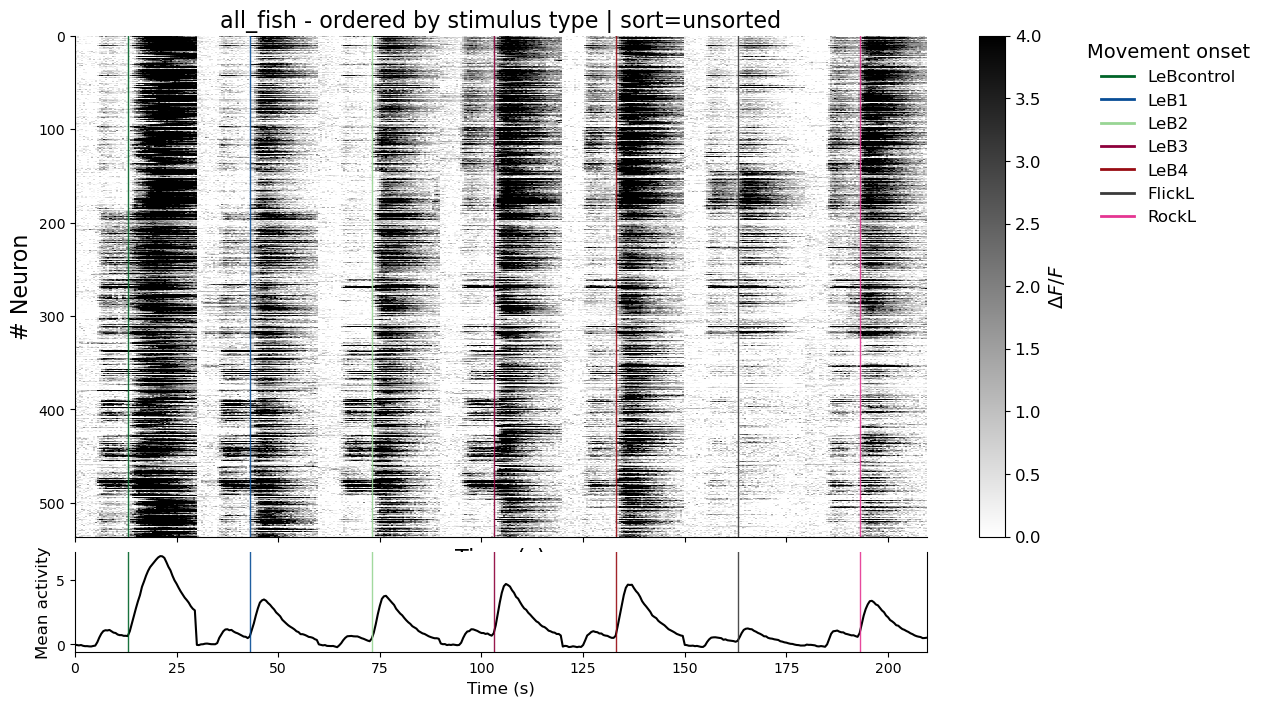

In [330]:
# Cell 11 - Plot left z-score raster
# Builds a pooled left-side z-score mean matrix and plots all fish without sorting.
# plot all fish together
#{'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}

#stim_order = [7,3,4,5,6,1,13,12,8,9,10,11,2,14]
#stim_order = [12,8,9,10,11,2,14]
stim_order = [7,3,4,5,6,1,13]
combine_mode = "mean"  # mean or concat
trace_type =  "zscore"#  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != M_all.shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match M_all rows.")
    M_all = M_all[plot_neuron_keep_mask, :]
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='unsorted',#,'unsorted',#,'corravg',      # or "pca", "hier", etc,unsorted, corravg
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=4,
        
)

# save_path.mkdir(parents=True, exist_ok=True)
# out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)


Final matrix shape: (536, 420)


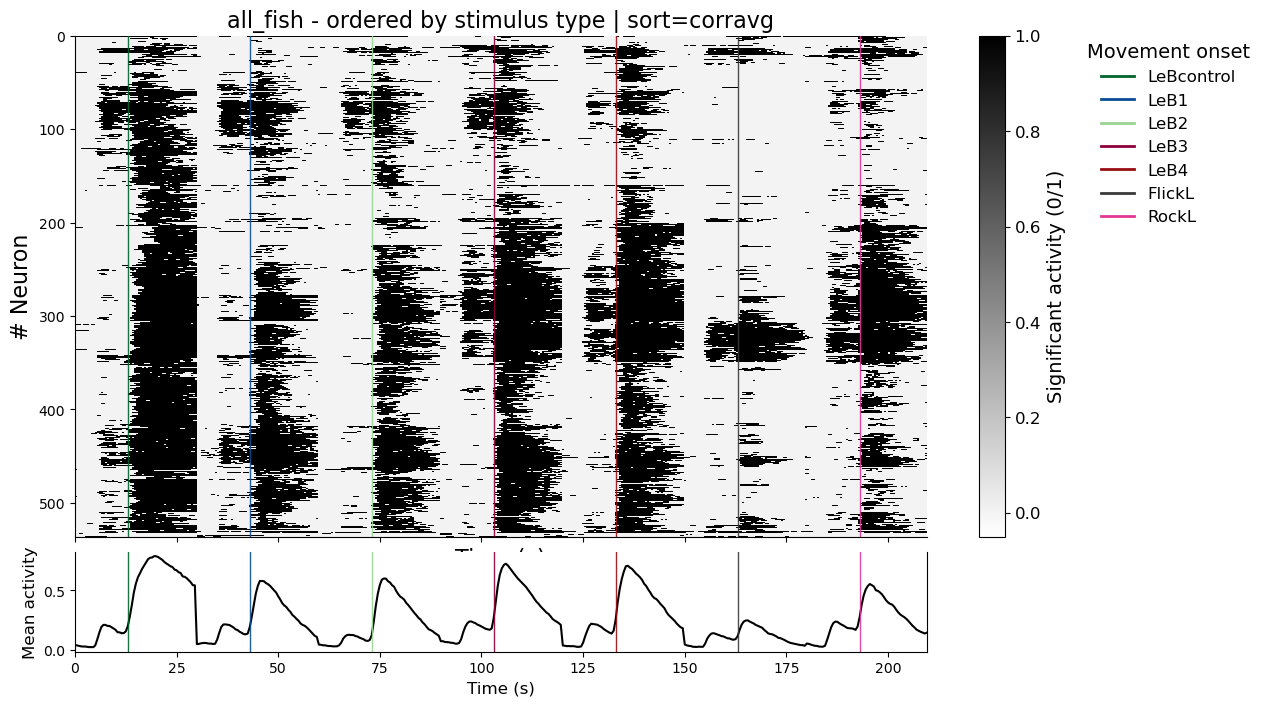

In [331]:
# Cell 12 - Plot left active raster
# Builds a pooled left-side binary raster and plots it using the previous neuron order.
stim_order = [7,3,4,5,6,1,13]
combine_mode = "mean"  # mean or concat
trace_type =  "raster"#  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != M_all.shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match M_all rows.")
    M_all = M_all[plot_neuron_keep_mask, :]
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='corravg',#,'unsorted',#,'corravg',      # or "pca", "hier", etc,unsorted, corravg
    n_clusters=3,
    random_state=0,
    neuron_order=neuron_order,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=True,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=1,
        
)


In [334]:
# Cell 15 - Pool mean traces
# Averages trials per fish/stimulus, then concatenates per-stimulus mean traces across fish.
## Organize by Left and Rigth response....
## First Concatenate mean traces across experiments
import numpy as np

# result: concat_mean_traces[stim] -> (sum_fish n_kept_neurons_fish, win_length)
concat_mean_traces = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in stimuli_ids}

for fid in fish_ids:
    trial_aligned_traces = all_fish_data[fid]["trial_aligned_traces"] # delta F/F 
    trial_aligned_traces_norm = all_fish_data[fid]["trial_aligned_traces_z_core"] # z-score
    kept_neuron_indices = all_fish_data[fid]["kept_neuron_indices"]

    for stim in stimuli_ids:
        X = trial_aligned_traces[stim]              # (n_neurons, win_length, n_trials)
        Xkept = X[kept_neuron_indices, :, :]        # (n_kept_fish, win_length, n_trials)
        mean_trace = np.nanmean(Xkept, axis=2)     # (n_kept_fish, win_length)
        mean_all_neurons = np.nanmean(mean_trace, axis=0)

        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(mean_all_neurons)

        Y = trial_aligned_traces_norm[stim]        # same as X but Global Norm
        mean_trace_norm = np.nanmean(Y, axis=2)
        mean_all_neurons_norm = np.nanmean(mean_trace_norm, axis=0)

        concat_mean_all_neurons_norm[stim].append(mean_all_neurons_norm)
# stack per stimulus along the neuron axis
for stim in stimuli_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])
# Example:
# big_mat_FL1 = concat_mean_traces['FL1']   # shape: (all_kept_neurons_all_fish, win_length)
print(concat_mean_all_neurons[stim].shape)
print(concat_mean_traces[stim].shape)

(5, 60)
(1665, 60)


new_stimuli_ids:   [7, 3, 4, 5, 6, 1, 13]
new_stimuli_names: ['LeBcontrol', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'FlickL', 'RockL']
shape of first M: (5, 60)
[warn] No linestyle for: ['LeBcontrol', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'FlickL', 'RockL'] → using solid '-'.


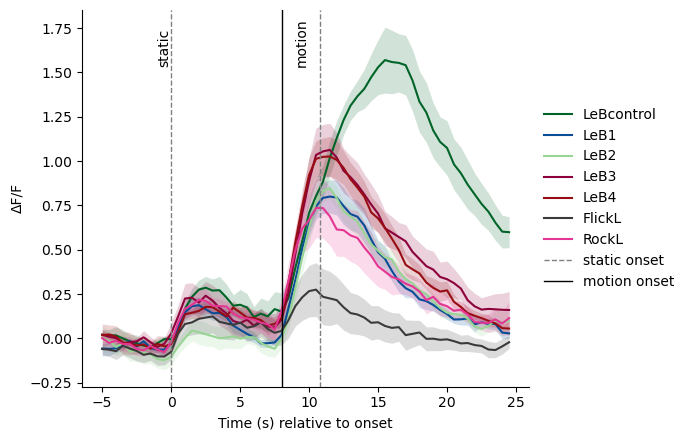

In [335]:
# Cell 16 - Plot right means
# Selects right-side stimuli and plots pooled normalized mean traces with stimulus styling.

stim_order = [12,8,9,10,11,2,14]

#stimuli_wanted = [0,1,2,3,4,7,8,9,5,6]  # positions in the list (0-based!)
#stimuli_wanted = [11,7,8,9,10,1,13] ## rigth
stimuli_wanted = [6,2,3,4,5,0,12] ## left
M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons_norm[stim_id]

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

print("new_stimuli_ids:  ", new_stimuli_ids)
print("new_stimuli_names:", new_stimuli_names)
# example: check one of the matrices
print("shape of first M:", M[new_stimuli_ids[0]].shape)


fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=M,
    stimuli_ids=new_stimuli_ids,
    stimuli_names=new_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=None,       # Path object or str
    prefix=None,               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)



Available stimuli (input_index, stim_id, real_name):
0: id=1, name=FlickL
1: id=2, name=FlickR
2: id=3, name=LeB1
3: id=4, name=LeB2
4: id=5, name=LeB3
5: id=6, name=LeB4
6: id=7, name=LeBcontrol
7: id=8, name=RiB1
8: id=9, name=RiB2
9: id=10, name=RiB3
10: id=11, name=RiB4
11: id=12, name=RiBcontrol
12: id=13, name=RockL
13: id=14, name=RockR
Selected stimuli (input_index, stim_id, real_name):
6: id=7, name=LeBcontrol
2: id=3, name=LeB1
3: id=4, name=LeB2
4: id=5, name=LeB3
5: id=6, name=LeB4
0: id=1, name=FlickL
12: id=13, name=RockL
Plotting stimuli: ['LeBcontrol', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'FlickL', 'RockL']


(<Figure size 1000x400 with 1 Axes>,
 array([<Axes: title={'center': 'Selected stimuli'}, xlabel='stimulus', ylabel='delta_integral'>],
       dtype=object))

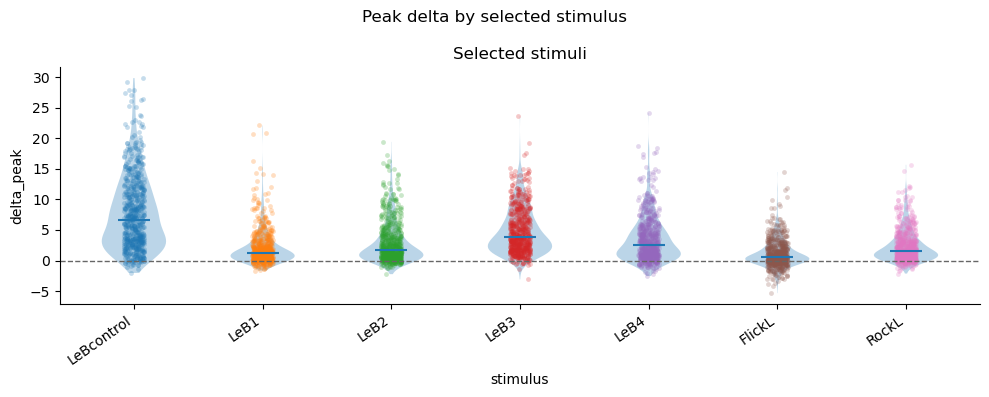

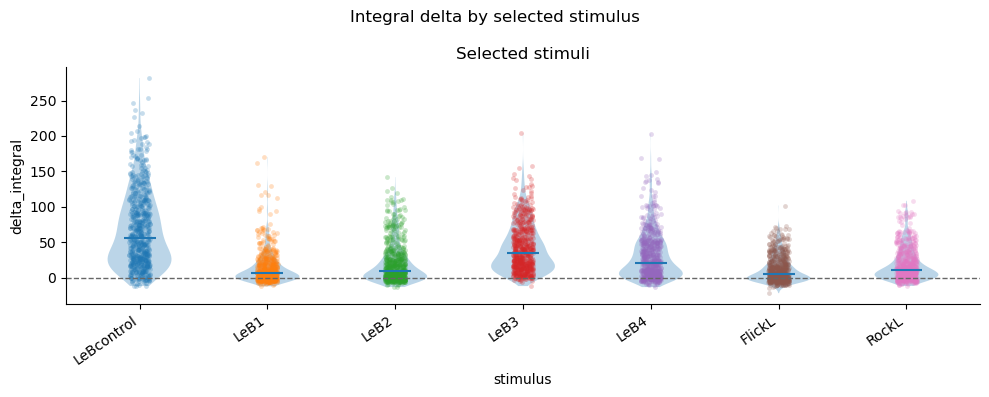

In [336]:
# Cell 17 - Motion deltas
# Computes integral and peak response deltas around motion onset for one fish and plots distributions.

import importlib
import src.analysis_tools as at
import src.plotting as plott

importlib.reload(at)
importlib.reload(plott)

fish_data = all_fish_data[fish_id]

# Manual input: positions in this fish's stimuli list (0-based).
# Change only this list to choose exactly which stimuli to plot.
stimuli_wanted = [6, 2, 3, 4, 5, 0, 12]

stimuli_ids_for_selection = fish_data.get("stimuli_ids", stimuli_ids)
stimuli_names_for_selection = fish_data.get("stimuli_names", stimuli_names)

print("Available stimuli (input_index, stim_id, real_name):")
for idx, (stim_id, stim_name) in enumerate(zip(stimuli_ids_for_selection, stimuli_names_for_selection)):
    print(f"{idx}: id={stim_id}, name={stim_name}")

selected_positions = [int(pos) for pos in stimuli_wanted]
bad_positions = [
    pos for pos in selected_positions
    if pos < 0 or pos >= len(stimuli_ids_for_selection)
]
if bad_positions:
    raise IndexError(
        f"stimuli_wanted contains invalid input indices {bad_positions}; "
        f"valid range is 0-{len(stimuli_ids_for_selection) - 1}."
    )
if not selected_positions:
    raise ValueError("stimuli_wanted must contain at least one input index.")

selected_stimuli_ids = [stimuli_ids_for_selection[pos] for pos in selected_positions]
selected_stimuli_names = [stimuli_names_for_selection[pos] for pos in selected_positions]

print("Selected stimuli (input_index, stim_id, real_name):")
for pos, stim_id, stim_name in zip(selected_positions, selected_stimuli_ids, selected_stimuli_names):
    print(f"{pos}: id={stim_id}, name={stim_name}")

kept_neuron_indices = fish_data["kept_neuron_indices"]
trial_aligned_z_kept = {
    stim_id: arr[kept_neuron_indices, :, :]
    for stim_id, arr in fish_data["trial_aligned_traces_z_core"].items()
}
missing_selected_ids = [stim_id for stim_id in selected_stimuli_ids if stim_id not in trial_aligned_z_kept]
if missing_selected_ids:
    raise KeyError(f"Selected stimulus IDs are missing trial-aligned z traces: {missing_selected_ids}")
selected_trial_aligned_z_kept = {
    stim_id: trial_aligned_z_kept[stim_id]
    for stim_id in selected_stimuli_ids
}

delta_df = at.compute_motion_delta_integrals(
    selected_trial_aligned_z_kept,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    pre_motion_fixed_s=8.0,
    stimuli_id_map=fish_data["stimuli_id_map"],
    stimuli_durations=fish_data["stimuli_durations"],
    fish_id=fish_id,
)

peak_df = at.compute_motion_delta_peaks(
    selected_trial_aligned_z_kept,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    pre_motion_fixed_s=8.0,
    stimuli_id_map=fish_data["stimuli_id_map"],
    stimuli_durations=fish_data["stimuli_durations"],
    fish_id=fish_id,
)

peak_df = peak_df[peak_df["stimulus"].isin(selected_stimuli_names)].copy()
delta_df = delta_df[delta_df["stimulus"].isin(selected_stimuli_names)].copy()

if delta_df.empty or peak_df.empty:
    raise ValueError("No motion-delta rows were computed for the selected stimuli.")

print("Plotting stimuli:", selected_stimuli_names)

plott.plot_motion_delta_distribution(
    peak_df,
    value_col="delta_peak",
    stimuli=selected_stimuli_names,
    title="Peak delta by selected stimulus",
)
plott.plot_motion_delta_distribution(
    delta_df,
    stimuli=selected_stimuli_names,
    title="Integral delta by selected stimulus",
)




In [337]:
# Cell 18 - Active matrices
# Reloads multi-fish helpers and builds active-neuron matrices plus counts with stricter thresholds.
import importlib
import src.multifish_analysis as mfa
importlib.reload(mfa)



active_matrices, active_counts = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data,
    tau_s=6.0,
    active_fraction_threshold=0.30,
    min_epoch_s=2.0,
    min_active_reps=2,
    expected_reps=4,
    return_counts=True,
)


Notebook-level neuron filter for pooled overlap kept 536 of 1665 neurons.


,Bcontrol,B1,B2,B3,B4,FlickL,Rock
Bcontrol,1.000000,0.677866,0.734252,0.779497,0.769826,0.236473,0.593320
B1,0.677866,1.000000,0.687356,0.655246,0.583505,0.250000,0.465784
B2,0.734252,0.687356,1.000000,0.723769,0.642710,0.290488,0.529670
B3,0.779497,0.655246,0.723769,1.000000,0.762605,0.272941,0.629712
B4,0.769826,0.583505,0.642710,0.762605,1.000000,0.267139,0.640449
FlickL,0.236473,0.250000,0.290488,0.272941,0.267139,1.000000,0.350000
Rock,0.593320,0.465784,0.529670,0.629712,0.640449,0.350000,1.000000


,Bcontrol,B1,B2,B3,B4,FlickL,Rock
Bcontrol,1.000000,0.227273,0.440000,0.483607,0.360784,0.052402,0.166667
B1,0.227273,1.000000,0.229412,0.178771,0.159763,0.071429,0.144000
B2,0.440000,0.229412,1.000000,0.419689,0.321429,0.077465,0.211765
B3,0.483607,0.178771,0.419689,1.000000,0.388298,0.054422,0.245509
B4,0.360784,0.159763,0.321429,0.388298,1.000000,0.060606,0.321918
FlickL,0.052402,0.071429,0.077465,0.054422,0.060606,1.000000,0.101266
Rock,0.166667,0.144000,0.211765,0.245509,0.321918,0.101266,1.000000


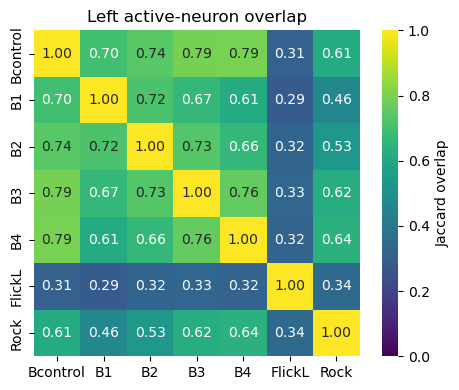

In [338]:
# Cell 19 - Pooled overlap
# Recomputes active matrices with default settings and plots pooled overlap for the chosen side.
from src.multifish_analysis import (
    build_active_neuron_matrices_all_fish,
    build_active_neuron_overlap_matrices_all_fish,
)

# Step 2: active-neuron overlap across B conditions

condition_labels = ["Bcontrol", "B1", "B2", "B3", "B4", "FlickL", "Rock"]

side_stimuli = {
    "left": [7, 3, 4, 5, 6,1,13],
    "right": [12, 8, 9, 10, 11,2,14],
}

active_matrices = build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=side_stimuli["left"] + side_stimuli["right"],
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
)

if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != response_row_metadata.shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match response_row_metadata rows.")

    filtered_active_matrices = {}
    for fid in fish_ids:
        fish_rows = response_row_metadata["fish_id"].to_numpy() == fid
        fish_keep_mask = plot_neuron_keep_mask[fish_rows]
        active_matrix = active_matrices[fid]
        if active_matrix.shape[0] != fish_keep_mask.shape[0]:
            raise ValueError(
                f"Active matrix rows for {fid} do not match response metadata rows: "
                f"{active_matrix.shape[0]} vs {fish_keep_mask.shape[0]}."
            )
        if hasattr(active_matrix, "loc"):
            filtered_active_matrices[fid] = active_matrix.loc[fish_keep_mask].reset_index(drop=True)
        else:
            filtered_active_matrices[fid] = active_matrix[fish_keep_mask, :]
    active_matrices = filtered_active_matrices
    print(
        "Notebook-level neuron filter for pooled overlap kept "
        f"{int(plot_neuron_keep_mask.sum())} of {plot_neuron_keep_mask.shape[0]} neurons."
    )

overlap_results = build_active_neuron_overlap_matrices_all_fish(
    active_matrices=active_matrices,
    side_stimuli=side_stimuli,
    condition_labels=condition_labels,
)

left_overlap_matrix = overlap_results["pooled"]["left"]
right_overlap_matrix = overlap_results["pooled"]["right"]

side_to_plot =  "left"#"left"  # or "right"
aggregation_to_plot = "mean_per_fish"#"pooled"  # or "mean_per_fish"
matrix_to_plot = overlap_results[aggregation_to_plot][side_to_plot]


display(left_overlap_matrix)
display(right_overlap_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matrix_to_plot,
    vmin=0,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Jaccard overlap"},
    ax=ax,
)
ax.set_title(f"{side_to_plot.capitalize()} active-neuron overlap")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()


Notebook-level neuron filter kept 536 of 1665 neurons.
trace_matrix: (536, 420)
decision_matrix: (536, 7)


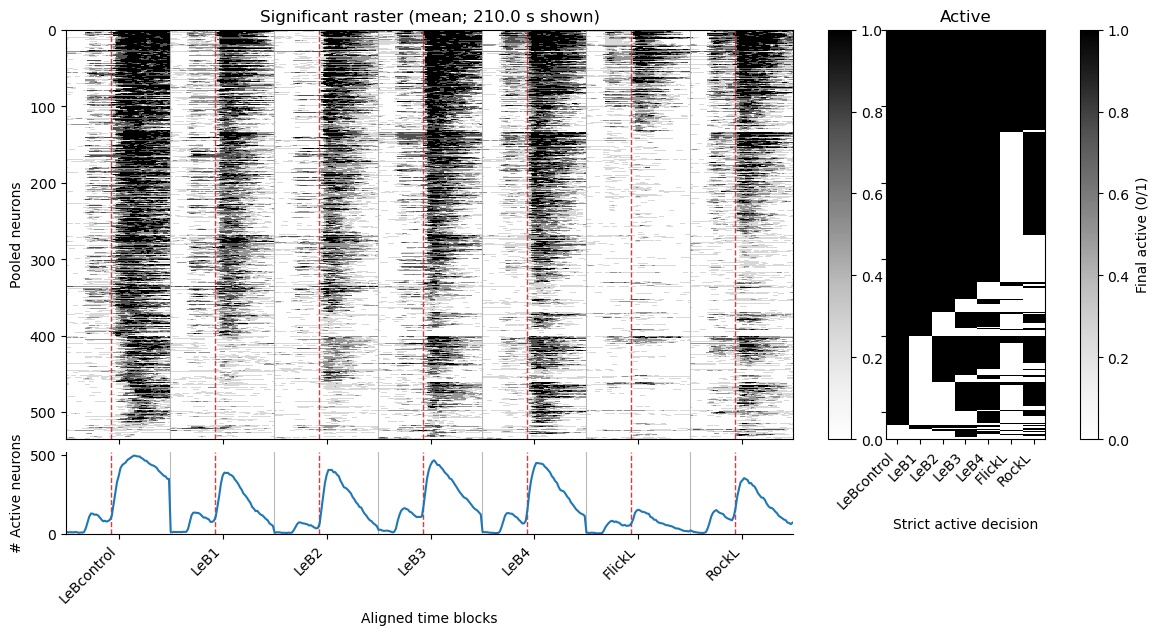

In [339]:
# Cell 20 - Decision diagnostic
# Builds and plots a pooled diagnostic comparing traces with active/inactive decisions.
from src.multifish_analysis import (
    build_active_neuron_matrices_all_fish,
    build_pooled_active_trace_diagnostic,
)

# Active-decision strictness diagnostic
# Choose any stimuli to inspect. Left B conditions shown by default.
diagnostic_stim_order = [7, 3, 4, 5, 6,1,13]  # LeBcontrol, LeB1, LeB2, LeB3, LeB4
# diagnostic_stim_order = [12, 8, 9, 10, 11]  # RiBcontrol, RiB1, RiB2, RiB3, RiB4
diagnostic_combine_mode = "mean"#"mean"  # "mean" or "concat"

active_matrices = build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=diagnostic_stim_order,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    tau_s=6.0,
    active_fraction_threshold=0.10,
    min_epoch_s=2.0,
    min_active_reps=2,
    expected_reps=4,
)

active_trace_diagnostic = build_pooled_active_trace_diagnostic(
    all_fish_data=all_fish_data,
    active_matrices=active_matrices,
    fish_ids=fish_ids,
    stim_order=diagnostic_stim_order,
    combine_mode=diagnostic_combine_mode,
)

if "plot_neuron_keep_mask" in globals():
    if plot_neuron_keep_mask.shape[0] != active_trace_diagnostic["trace_matrix"].shape[0]:
        raise ValueError("plot_neuron_keep_mask length does not match active_trace_diagnostic rows.")
    active_trace_diagnostic = active_trace_diagnostic.copy()
    active_trace_diagnostic["trace_matrix"] = active_trace_diagnostic["trace_matrix"][plot_neuron_keep_mask, :]
    active_trace_diagnostic["decision_matrix"] = active_trace_diagnostic["decision_matrix"][plot_neuron_keep_mask, :]
    active_trace_diagnostic["row_metadata"] = active_trace_diagnostic["row_metadata"].loc[
        plot_neuron_keep_mask
    ].reset_index(drop=True)
    print(
        "Notebook-level neuron filter kept "
        f"{int(plot_neuron_keep_mask.sum())} of {plot_neuron_keep_mask.shape[0]} neurons."
    )

if active_trace_diagnostic["trace_matrix"].shape[0] == 0:
    fig = None
    axes = None
    diagnostic_neuron_order = np.array([], dtype=int)
    print("No neurons passed the current filters; diagnostic plot was not drawn.")
else:
    fig, axes, diagnostic_neuron_order = plott.plot_active_trace_decision_diagnostic(
        active_trace_diagnostic,
        fps_2p=fps_2p,
        stimuli_durations=stimuli_durations,
        t_pre_s=t_pre_s,
        sort_mode="decision_then_mean",
        show_active_count_trace=True,
        active_count_threshold=0.5,
        figsize=(12, 7),
    )

print("trace_matrix:", active_trace_diagnostic["trace_matrix"].shape)
print("decision_matrix:", active_trace_diagnostic["decision_matrix"].shape)
